In [1]:
# Imports
import pandas as pd
from biom import load_table
import numpy as np
import qiime2 as q2
import patsy
import statsmodels.api as smetabolitem
from skbio.stats.composition import clr, multiplicative_replacement
from scipy.stats import spearmanr, pearsonr, kruskal, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.linear_model import LinearRegression

import re
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import pingouin as pg
import networkx as nx

In [2]:
# Load Feature Tables

fts = {
    'Nightingale': pd.read_csv('../data/Nightingale.csv', dtype={'sample_name': str}).set_index('sample_name'),
       # 'Baker': pd.read_csv('../data/Baker.csv', dtype={'sample_name': str}).set_index('sample_name'),
       'Metabolon': pd.read_csv('../data/Metabolon.csv', dtype={'sample_name': str}).set_index('sample_name'),
       # 'Wishart': pd.read_csv('../data/wishart_combined.csv', dtype={'sample_name': str}).set_index('sample_name'),
       # 'Fiehn': pd.read_csv('../data/WCMC (FIEHN).csv', dtype={'sample_name': str}).set_index('sample_name'),
       'UCSD': pd.read_csv('../data/UCSD Known.csv', dtype={'sample_name': str}).set_index('sample_name'),
       # 'Tuulia': pd.read_csv('../data/Tuulia Known.csv', dtype={'sample_name': str}).set_index('sample_name'),
       'Metagenomics': load_table('../data/micov_filtered_feature-table_matched.biom').to_dataframe().T
      }

In [3]:
fts['Metagenomics']

,G000006605,G000006785,G000006845,G000006865,G000006925,G000007145,G000007265,G000007325,G000007465,G000007485,...,G902787525,G902788545,G902790905,G902791625,G902792045,G902792985,G902798515,G902799415,G902801825,G902801975
15448.0042180541,1.0,3.0,1.0,7.0,235.0,0.0,4.0,0.0,1.0,0.0,...,16.0,6.0,0.0,15.0,2.0,6.0,1.0,3.0,1.0,13.0
15448.0042239290,0.0,1.0,0.0,70.0,1777.0,0.0,1.0,0.0,1.0,0.0,...,2.0,30.0,251.0,0.0,1.0,15.0,0.0,21.0,0.0,0.0
15448.0042036365,21.0,9.0,0.0,49.0,11731.0,0.0,9.0,0.0,10.0,0.0,...,17.0,3.0,37.0,7.0,5.0,5.0,1.0,110.0,1.0,0.0
15448.0042149798,0.0,2.0,0.0,29.0,208.0,0.0,4.0,1.0,0.0,0.0,...,25.0,3.0,7.0,78.0,0.0,9.0,2.0,4.0,3.0,31.0
15448.0042121151,0.0,0.0,0.0,10.0,3.0,0.0,0.0,0.0,0.0,0.0,...,10.0,0.0,191.0,3.0,3.0,30.0,0.0,12.0,0.0,54.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15448.42430221,0.0,0.0,0.0,0.0,6520.0,0.0,1.0,0.0,1.0,0.0,...,0.0,41.0,61.0,21.0,8.0,83.0,1.0,104.0,2.0,4.0
15448.42368299,1.0,7.0,20.0,22.0,27.0,0.0,7.0,1.0,10.0,0.0,...,60.0,12.0,259.0,13.0,4.0,13.0,2.0,164.0,0.0,0.0
15448.42413913,0.0,35.0,0.0,13.0,8030.0,0.0,29.0,0.0,12.0,0.0,...,0.0,15.0,1.0,0.0,26.0,0.0,0.0,1.0,0.0,0.0
15448.42231863,0.0,2.0,0.0,20.0,386.0,0.0,2.0,8.0,1.0,0.0,...,0.0,85.0,0.0,0.0,1.0,8.0,0.0,5.0,0.0,0.0


In [4]:
fts['Metabolon']

,S.1.pyrroline.5.carboxylate,spermidine,X1.methylnicotinamide,X12.13.DiHOME,alpha.ketoglutarate,kynurenate,X3.hydroxyisobutyrate,X3.hydroxy.3.methylglutarate,X3.phosphoglycerate,cholate,...,X.26054,X.26066,X.26097,X.26106,X.26107,X.26108,X.26109,X.26111,X.26119,X.26220
sample_name,,,,,,,,,,,,,,,,,,,,,
15448.42368322,0.500443,0.205782,1.836061,1.519002,-0.473346,-0.185729,-0.251341,-0.310168,-0.872150,0.146514,...,-0.656744,-0.769012,0.034000,-0.429061,-0.289161,-0.233526,-1.709261,-1.824297,-1.656386,-0.176307
15448.42209258,0.333516,0.327006,-0.649584,2.132159,0.044300,-0.895474,-0.594008,0.208350,0.063400,0.876802,...,-0.171069,0.597616,0.682811,-2.034050,-1.808583,-1.079082,-1.321478,-3.193517,-1.046514,-0.414742
15448.42385333,0.095800,0.206304,0.916201,-0.532121,-0.274325,0.435237,0.119635,-0.717340,-1.439912,1.386431,...,0.487774,0.908330,-0.213125,-0.230733,-0.323591,-0.017900,1.108202,1.044445,-0.292413,0.521058
15448.42372244,0.033400,0.987762,-0.299469,0.777254,-0.337295,-0.084800,0.973127,-0.424786,0.641426,2.545903,...,-0.121642,0.032400,-0.761810,0.936658,1.014449,0.786893,0.299608,-2.647761,-1.212894,0.524362
15448.42326795,0.324548,-0.651410,0.183551,-1.183937,-0.352402,1.023891,0.304110,0.017800,-0.998951,-1.387121,...,0.599603,0.177928,0.233219,0.885304,0.742840,0.541475,-0.615148,0.924644,-0.801685,-0.320219
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15448.0042121186,-0.022600,0.112886,-1.217705,-0.048000,-0.324309,-0.321642,-0.820391,0.139263,-0.443441,1.359525,...,-0.059000,-0.716135,0.151789,0.013300,0.303523,-0.342461,-0.415223,-1.063180,-0.236117,0.044600
15448.42556374,-0.036000,-0.930179,0.294622,0.405091,-0.193254,-1.159028,0.279137,0.527521,-1.295912,4.844854,...,-0.099200,0.362925,-0.007370,-0.045600,0.477847,1.430494,-1.264956,-0.036000,0.136211,-0.726048
15448.42593049,-0.183255,0.747917,1.018266,1.979948,-0.335205,-0.137641,1.101098,-0.316024,1.301390,3.410716,...,-0.103869,0.389225,-0.289771,0.802284,0.649892,0.648924,-0.321302,0.927316,1.162551,2.013184


In [5]:
# And metadata
md = pd.read_csv('../data/plasma_metadata_matched_main_outcomes.tsv', sep = '\t', dtype={'UCSD': str, 'Unnamed: 0': str, 'sample_name': str}).set_index('sample_name')

In [6]:
md

,Diagonsis,fiber,Amyloid PET,CRAFTDRE,Amyloid CSF,Hippocampal Atrophy,Tau PET,Tau CSF,MOCA,UDSBENTD,...,HEI2015_Greens_Beans,HEI2015_Whole_Grains,HEI2015_Dairy,HEI2015_Protein_Foods,HEI2015_SeaFoods_PlantProteins,HEI2015_Fatty_Acids,HEI2015_Refined_Grains,HEI2015_Sodium,HEI2015_Saturated_Fat,HEI2015_Added_Sugars
sample_name,,,,,,,,,,,,,,,,,,,,,
15448.42368322,Cognitively Unimpaired,NaN,NaN,13.0,NaN,NaN,NaN,NaN,23.0,14.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15448.42209258,Cognitively Unimpaired,39.856434,NaN,21.0,NaN,1.0,NaN,NaN,29.0,15.0,...,5.0,4.7,9.3,5.0,5.0,7.2,10.0,5.7,3.421491,9.186920
15448.42385333,Cognitively Unimpaired,14.781425,NaN,17.0,0.0,0.0,NaN,0.0,27.0,13.0,...,0.8,0.7,9.7,4.5,0.5,0.3,9.6,3.9,0.000000,7.455456
15448.42372244,Cognitively Impaired,NaN,NaN,0.0,NaN,NaN,NaN,NaN,20.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15448.42326795,Cognitively Unimpaired,NaN,0.0,14.0,NaN,0.0,0.0,NaN,24.0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15448.0042121186,Cognitively Unimpaired,85.491783,NaN,17.0,NaN,NaN,NaN,NaN,26.0,10.0,...,5.0,1.6,4.2,5.0,5.0,6.4,0.0,2.6,7.242449,10.000000
15448.42556374,Cognitively Unimpaired,31.642000,0.0,14.0,NaN,1.0,0.0,NaN,23.0,11.0,...,5.0,3.8,6.8,5.0,5.0,2.8,5.3,0.0,5.021415,9.820618
15448.42593049,Cognitively Impaired,NaN,NaN,11.0,NaN,0.0,NaN,NaN,29.0,11.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Save non clr version of feature table
non_clr = fts['Metagenomics']

In [8]:
# Multiplicative CLR for metagenomics 

def multiplicative_clr(df):
    metagenomic_counts = np.array(df)  

    # Replace zeros using multiplicative replacement
    metagenomic_counts = multiplicative_replacement(metagenomic_counts)

    # Apply CLR transformation
    clr_transformed_data = clr(metagenomic_counts)

    df = pd.DataFrame(clr_transformed_data,index=df.index, columns=df.columns)
    return df


fts['Metagenomics'] = multiplicative_clr(fts['Metagenomics'])

In [9]:

# fts['Metagenomics'].to_excel("../data/ADRC_metabolomics_matched_CLR_metagenomics_feature-table.xlsx")

## Correlate all microbes with all metabolites across 7 platforms while controlling for confounders

In [10]:
resid = {}

# covariates
covars_raw = md[["NACCAGE", 'SEX', "site"]].copy()

# make sure numeric cols are numeric (coerce weird strings to NaN)
for c in ["NACCAGE"]:
    covars_raw[c] = pd.to_numeric(covars_raw[c], errors="coerce")

# one-hot encode categoricals
covars = pd.get_dummies(covars_raw, columns=["site",'SEX'], drop_first=True)

# replace inf -> NaN, then drop rows with any missing covariate
covars = covars.replace([np.inf, -np.inf], np.nan).dropna(axis=0)


def residualize(matrix: pd.DataFrame, covars: pd.DataFrame) -> pd.DataFrame:
    # align samples
    common = matrix.index.intersection(covars.index)
    X_all = covars.loc[common]

    out = pd.DataFrame(index=common, columns=matrix.columns, dtype=float)

    for col in matrix.columns:
        y_all = pd.to_numeric(matrix.loc[common, col], errors="coerce")
        y_all = y_all.replace([np.inf, -np.inf], np.nan)

        ok = y_all.notna() & np.isfinite(y_all) & X_all.notna().all(axis=1)
        if ok.sum() < (X_all.shape[1] + 2):
            continue  # not enough rows to fit

        X = X_all.loc[ok]
        y = y_all.loc[ok]

        model = LinearRegression().fit(X, y)
        out.loc[ok, col] = y - model.predict(X)

    return out

for ft, mat in fts.items():
    resid[ft] = residualize(mat, covars)


In [11]:
#correlating all microbes + metabolites 
results_df = {}


for ft in resid.keys():
    if ft != 'Metagenomics':
        print(ft)
        # 1) Align samples and drop any row with NaNs for speed
        X = resid[ft].sort_index()
        X = X.dropna(axis=0, how='any')
        Y = resid['Metagenomics'].sort_index()
        Y = Y.loc[Y.index.intersection(X.index)]
        XY = (
            pd.concat([X, Y], axis=1, join="inner")
        )
        m, n = X.shape[1], Y.shape[1]
        Xc = XY.iloc[:, :m].to_numpy()
        Yc = XY.iloc[:, m:].to_numpy()

        # 2) One-shot Spearman on all columns
        corr_full, p_full = spearmanr(np.concatenate([Xc, Yc], axis=1), axis=0)
        # 3) Take the metabolite×microbe block
        corr = corr_full[:m, m:]
        pvals = p_full[:m, m:]

        # 4) FDR
        qvals = multipletests(pvals.ravel(), method="fdr_bh")[1].reshape(pvals.shape)

        # 5) Wrap as DataFrames (optional)
        corr_df = pd.DataFrame(corr, index=X.columns, columns=Y.columns)
        p_df    = pd.DataFrame(pvals, index=X.columns, columns=Y.columns)
        q_df    = pd.DataFrame(qvals, index=X.columns, columns=Y.columns)


        # Long-form results: one row per (metabolite, microbe)
        results_df[ft] = (
            corr_df.stack().rename("corr").to_frame()
            .join(p_df.stack().rename("p_value"))
            .join(q_df.stack().rename("q_value"))
            .reset_index()
            .rename(columns={"level_0": "metabolite", "level_1": "microbe"})
        )
        
        results_df[ft]['Platform'] = ft

Nightingale
Metabolon
UCSD


In [12]:
# Save signifianct results

sig_results = {}

for ft in fts.keys():
    if ft != 'Metagenomics':
        sig_results[ft] = results_df[ft][results_df[ft]['q_value'] < .05]
        
all_sig_results = pd.concat(sig_results.values())
all_results = pd.concat(results_df.values())

In [13]:
# Short values bu correlation
all_sig_results = all_sig_results.sort_values(by='corr', key=abs, ascending=False)

In [14]:
all_sig_results

,metabolite,microbe,corr,p_value,q_value,Platform
2421330,X.11850,G004558915,0.511642,5.687764e-35,1.631723e-28,Metabolon
2413203,X.11843,G004558915,0.504062,7.805410e-34,1.119620e-27,Metabolon
2420090,X.11850,G000435995,0.498531,5.063300e-33,4.841917e-27,Metabolon
2413065,X.11843,G003343915,0.494333,2.046558e-32,1.291788e-26,Metabolon
2421192,X.11850,G003343915,0.494044,2.251418e-32,1.291788e-26,Metabolon
...,...,...,...,...,...,...
199454,bOHbutyrate,G001553955,-0.141315,1.829845e-03,4.998606e-02,Nightingale
631992,M_HDL_C_pct,G000424105,0.141315,1.829859e-03,4.998606e-02,Nightingale
649982,S_HDL_CE_pct,G900240275,-0.141314,1.830006e-03,4.998797e-02,Nightingale
510802,M_VLDL_C_pct,G001311355,-0.141313,1.830108e-03,4.998869e-02,Nightingale


In [15]:
def get_most_specific_taxon(taxonomy):
    levels = [t.strip() for t in taxonomy.split(';')]
    
    # Go from most specific → least specific
    for level in reversed(levels):
        # Skip empty or unassigned levels (like s__ or g__)
        if level and not level.endswith('__'):
            return level
    
    return 'Unclassified'

In [16]:
# Add taxnony to results tables

tax = pd.read_csv('/home/lakhatib/wol_tree/taxonomy.tsv', sep = '\t', index_col='Feature ID')
all_results = all_results.set_index('microbe')
all_sig_results = all_sig_results.set_index('microbe')

all_sig_results['Taxonomy'] = tax['Taxon']
all_sig_results = all_sig_results.reset_index(drop=False)

all_results['Taxonomy'] = tax['Taxon']
all_results = all_results.reset_index(drop=False)

In [17]:
all_sig_results['species'] = all_sig_results['Taxonomy'].apply(get_most_specific_taxon)

In [18]:
all_sig_results['feature_id'] = all_sig_results['species'] + '; ' + all_sig_results['microbe']

In [19]:
all_sig_results['class'] = all_sig_results['Taxonomy'].str.extract(r'c__([^;]+)')

In [20]:
# # Extract species name

# all_sig_results['species'] = [taxonomy.split(';')[-1].strip() for taxonomy in all_sig_results['Taxonomy']]

# all_sig_results['feature_id'] = all_sig_results['Taxonomy'] + '; ' + all_sig_results['microbe']

In [21]:
# Keep top 50 most correlated species
top_microbes = all_sig_results['feature_id'].value_counts().sort_values(ascending=False).head(50)

In [22]:
all_sig_results = all_sig_results.set_index('feature_id')

In [23]:
# Create DataFrame for plotting
top_df = top_microbes.reset_index()

In [24]:
top_df = top_df.set_index('index')

In [25]:
no_dup = all_sig_results[~all_sig_results.index.duplicated()]

In [26]:
top_df['class'] = no_dup['class']

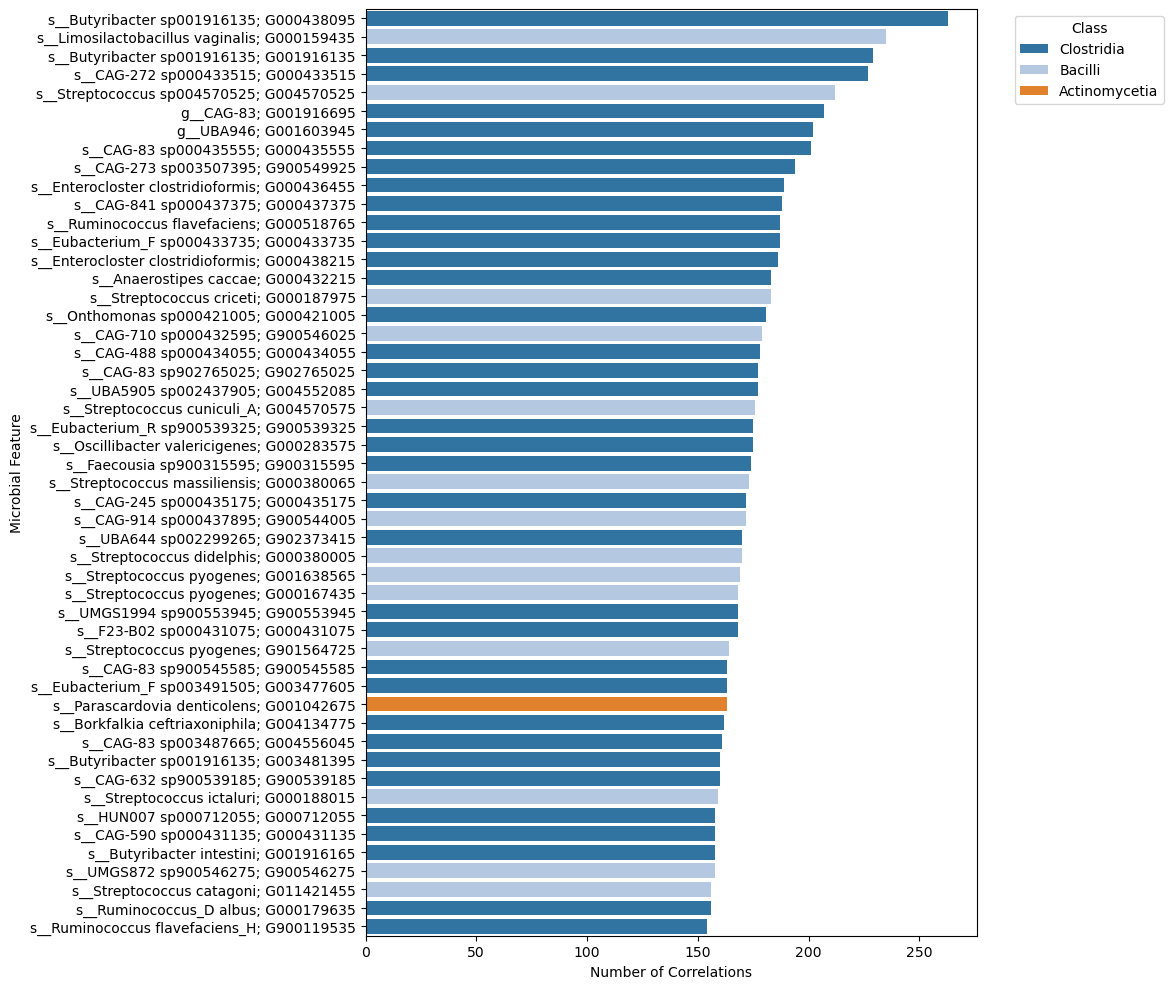

In [27]:
# def species_with_prev(label):
#     # Extract species
#     m_sp = re.search(r's__([^:(]+)', label)
#     species = m_sp.group(1).strip() if m_sp else re.sub(r'\b[a-z]__', '', label).split(':')[0].strip()
#     # Extract prevalence (the number inside parentheses)
#     m_prev = re.search(r'\(prev:\s*[\d.]+%\)', label)
#     prev = m_prev.group(0) if m_prev else ''
#     return f"{species} {prev}".strip()


# Create DataFrame for plotting
top_df = top_df.reset_index()
# top_df.columns = ['featureid', 'high_corr_count']

# # Extract class from the featureid
# top_df['class'] = top_df['featureid'].str.extract(r'c__([^;]+)')

# # Now clean the index (after reindexing)
# top_df['featureid_clean'] = top_df['featureid'].apply(species_with_prev)

# Plot
plt.figure(figsize=(12, 10))
sns.barplot(
    data=top_df,
    y='index',
    x='feature_id',
    hue='class',
    dodge=False,
    palette='tab20'
)

plt.xlabel("Number of Correlations")
plt.ylabel("Microbial Feature")
plt.title(f"")
plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f'../figures/top_50_correlated_microbes.png', bbox_inches='tight')
plt.show()


## Correlate all microbes + metabolites with MOCA scores

In [28]:
all_sig_results = all_sig_results.reset_index()

In [29]:
# Extract OGUs
top_ogus = all_sig_results['microbe'].value_counts().sort_values(ascending=False).head(50).index

In [30]:
sig_resid = {}

sig_resid['Metagenomics'] = resid['Metagenomics'][top_ogus]

In [31]:
# Filter feature table to sig features

for ft in resid.keys():
    if ft != 'Metagenomics':
        sig_resid[ft] = resid[ft][resid[ft].columns[resid[ft].columns.isin(all_sig_results['metabolite'])]]

In [32]:
cog = md['MOCA'].dropna()

In [33]:
covars_cog = covars.loc[covars.index.intersection(cog.index)]

In [34]:
# cog = cog.loc[cog.index.intersection(covars_cog.index)]

In [35]:
common_idx = covars_cog.index.intersection(cog.index)

X = covars_cog.loc[common_idx]
y = cog.loc[common_idx]

cog_resid = y - LinearRegression().fit(X, y).predict(X)

In [36]:
cog_resid = cog - LinearRegression().fit(covars_cog, cog).predict(covars_cog)

In [37]:
sig_resid['Metagenomics'] = sig_resid['Metagenomics'].loc[:, ~sig_resid['Metagenomics'].columns.duplicated()]

In [38]:
#linking all features to MoCA scores

moca_df = {}

for ft in fts.keys():
    print(ft)
    df = sig_resid[ft].copy()
    df['MOCA_corr'] = cog_resid

    df = df.dropna()
    metabs = df.columns

    # Run Spearman for each metabolite vs moca
    r_vals = []
    p_vals = []
    for col in metabs:
        r, p = spearmanr(df[col], df["MOCA_corr"])
        r_vals.append(r)
        p_vals.append(p)

    # Adjust for multiple testing
    q_vals = multipletests(p_vals, method="fdr_bh")[1]

    # Put in a DataFrame
    moca_df[ft] = pd.DataFrame({
        'Platform': ft,
        'Feature': metabs,
        "moca_r": r_vals,
        "moca_p": p_vals,
        "moca_q": q_vals
    })


Nightingale
Metabolon
UCSD
Metagenomics


In [39]:
# Filter to metagenomics significantly correlated to moca
moca_metag = moca_df['Metagenomics'][moca_df['Metagenomics']['moca_q'] < .05]

In [40]:
moca_metag = moca_metag.set_index('Feature')
moca_metag['Taxonomy'] = tax['Taxon']

In [41]:
moca_metag['class'] = moca_metag['Taxonomy'].str.extract(r'c__([^;]+)')

In [42]:
moca_metag = moca_metag.dropna()

In [43]:
moca_metag['species'] = moca_metag['Taxonomy'].apply(get_most_specific_taxon)

In [44]:
moca_metag = moca_metag.reset_index(drop=False)

In [45]:
moca_metag['feature_id'] = moca_metag['species'] + '; ' + moca_metag['Feature']

In [46]:
moca_metag = moca_metag[['feature_id', 'class', 'moca_r']]

In [47]:
moca_metag = moca_metag.sort_values(by='moca_r', ascending=False)

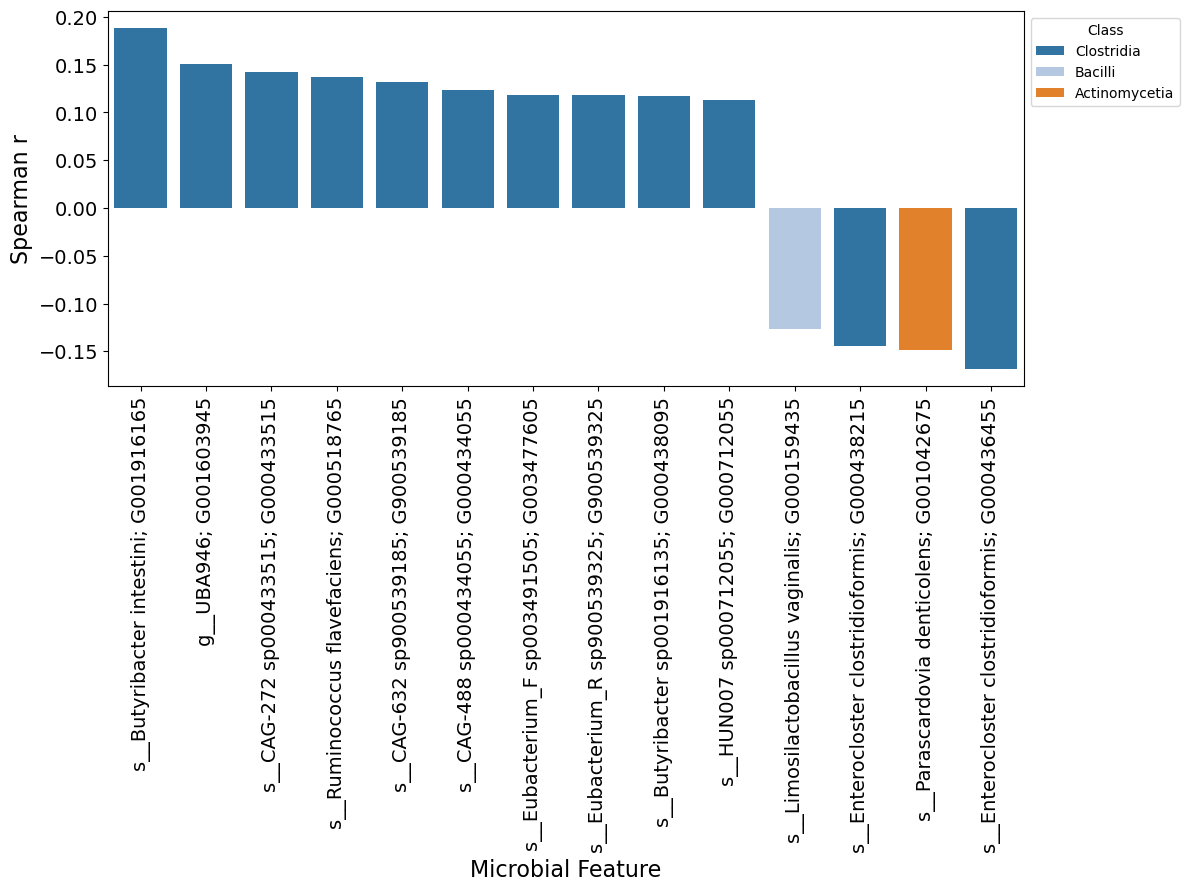

In [53]:
# Plot top OGUs

# Step 4: Plot
plt.figure(figsize=(12, 9))
sns.barplot(
    data=moca_metag,
    y='moca_r',
    x='feature_id',
    hue='class',
    dodge=False,
    palette='tab20'
)

plt.xlabel("Microbial Feature", fontsize=16)
plt.xticks(rotation=90, fontsize=14)
plt.yticks(fontsize=14)
plt.ylabel("Spearman r", fontsize=16)
plt.title(f"")
plt.legend(title='Class', bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f'../figures/top_moca_correlated_microbes.png', bbox_inches='tight')
plt.show()


In [54]:
moca_df_sig = moca_df['Metagenomics'][moca_df['Metagenomics']['moca_q'] < .05]

In [55]:
sig_resid['Metagenomics'][moca_df_sig['Feature'][:-1]].to_csv('../output_files/significant_moca_microbes_residualized.csv')

In [56]:
# Filter microbe/metabolite table to only include microbes correlated to moca

top_sig = all_sig_results[all_sig_results['feature_id'].isin(moca_metag['feature_id'])]

In [59]:
# # Clean feature IDs

# top_sig['featureid_clean'] = top_sig['feature_id'].apply(species_with_prev)

In [60]:
# Add all moca correlation dataframes together

moca_df = pd.concat(moca_df.values())

moca_df = moca_df.rename(columns={'Feature': 'metabolite'})

In [61]:
# Add a significance flag (q < 0.05)
moca_df["metab_sig"] = moca_df["moca_q"] < 0.05

# Merge onto correlation df
top_sig = top_sig.merge(
    moca_df[["metabolite", "metab_sig"]],
    on="metabolite",
    how="left"
)

In [62]:
# Filter to sig results only
top_sig = top_sig[top_sig['metab_sig'] == True]

In [63]:
# Only keep the metabolite and moca info we need
moca_keep = moca_df[['metabolite', 'moca_r']]

# Merge onto df
df_merged = top_sig.merge(moca_keep, on='metabolite', how='left')

In [64]:
moca_metag

,feature_id,class,moca_r
13,s__Butyribacter intestini; G001916165,Clostridia,0.188355
3,g__UBA946; G001603945,Clostridia,0.150918
2,s__CAG-272 sp000433515; G000433515,Clostridia,0.142521
5,s__Ruminococcus flavefaciens; G000518765,Clostridia,0.137550
11,s__CAG-632 sp900539185; G900539185,Clostridia,0.132314
7,s__CAG-488 sp000434055; G000434055,Clostridia,0.123856
9,s__Eubacterium_F sp003491505; G003477605,Clostridia,0.118468
8,s__Eubacterium_R sp900539325; G900539325,Clostridia,0.118160
0,s__Butyribacter sp001916135; G000438095,Clostridia,0.117661
12,s__HUN007 sp000712055; G000712055,Clostridia,0.112654


In [65]:
# Clean moca metag dataframe and add it to df_merged

moca_metag = moca_metag.rename(columns={'moca_r': 'metag_moca_r'})
df_merged = df_merged.merge(moca_metag, on='feature_id', how='left')

In [66]:
# Rename columns for clarity
df_merged = df_merged.rename(columns={'corr': 'microbe_metabolite_r', 'moca_r': 'metab_moca_r', 'featureid_clean': 'microbe_w_tax'})

In [69]:
# Filter columns and save
df_merged = df_merged[['feature_id', 'metabolite', 'microbe_metabolite_r', 'p_value', 'q_value', 'Platform', 'metag_moca_r', 'metab_moca_r']]

In [70]:
# Sort by microbe-metabolite corr 
df_merged = df_merged.sort_values(by='microbe_metabolite_r', key=abs, ascending=False)

In [71]:
# Add positive/negative column for plotting

df_merged['metag_moca_dir'] = np.where(df_merged['metag_moca_r'] > 0, 'Positive', 'Negative')
df_merged['metab_moca_dir'] = np.where(df_merged['metab_moca_r'] > 0, 'Positive', 'Negative')

In [72]:
# save cleaned results dataframe
df_merged.to_csv('../output_files/sig_metab_metag_results.csv')

# Plot all microbe-metabolite correlations associated with MOCA scores

In [73]:
df_plot = pd.read_csv('/home/lakhatib/ADRC_plasma/data/Lora_microbe_metabolite_results_NK.csv', index_col=0)

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec



def plot_corr(df, platform, figsize=(10, 12)):
    df = df.copy()

    # -----------------------------
    # Sorting
    # -----------------------------
    dir_rank = {'Positive': 0, 'Negative': 1}
    df['metab_dir_rank'] = df['metab_moca_dir'].map(dir_rank)
    df['metag_dir_rank'] = df['metag_moca_dir'].map(dir_rank)

    df_sorted_x = df.sort_values(
        by=['Platform', 'metab_dir_rank', 'microbe_metabolite_r'],
        ascending=[True, True, True]
    )
    metabolite_order = df_sorted_x['abbreviated_name'].unique()

    df_sorted_y = df.sort_values(
        by=['metag_dir_rank', 'microbe_metabolite_r'],
        ascending=[True, True]
    )
    microbe_order = df_sorted_y['feature_id'].unique()

    df['metabolite'] = pd.Categorical(df['abbreviated_name'],
                                      categories=metabolite_order, ordered=True)
    df['feature_id'] = pd.Categorical(df['feature_id'],
                                         categories=microbe_order, ordered=True)

    # -----------------------------
    # Cognition values
    # -----------------------------
    metabolite_cog = (
        df.drop_duplicates('metabolite')
          .set_index('metabolite')
          .loc[metabolite_order, 'metab_moca_r']
    )

    microbe_cog = (
        df.drop_duplicates('feature_id')
          .set_index('feature_id')
          .loc[microbe_order, 'metag_moca_r']
    )

    vmax = np.nanmax(np.abs(np.concatenate([
        metabolite_cog.values.astype(float),
        microbe_cog.values.astype(float)
    ])))
    if np.isnan(vmax) or vmax == 0:
        vmax = 1

    # -----------------------------
    # Layout (BOTTOM STRIP)
    # -----------------------------
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(
        nrows=2, ncols=2,
        width_ratios=[0.2, 11],
        height_ratios=[11, 0.4],   # bottom strip instead of top
        wspace=0.02, hspace=0.05
    )

    ax_left = fig.add_subplot(gs[0, 0])   # microbe strip
    ax = fig.add_subplot(gs[0, 1])        # main plot
    ax_bottom = fig.add_subplot(gs[1, 1]) # metabolite strip

    # -----------------------------
    # Left heatmap (microbes)
    # -----------------------------
    sns.heatmap(
        np.array(microbe_cog.values).reshape(-1, 1),
        ax=ax_left,
        cmap='coolwarm',
        center=0,
        vmin=-vmax,
        vmax=vmax,
        cbar=False,
        xticklabels=False,
        yticklabels=False
    )

    # -----------------------------
    # Bottom heatmap (metabolites)
    # -----------------------------
    sns.heatmap(
        np.array([metabolite_cog.values]),
        ax=ax_bottom,
        cmap='coolwarm',
        center=0,
        vmin=-vmax,
        vmax=vmax,
        cbar=False,
        xticklabels=False,
        yticklabels=False
    )

    # -----------------------------
    # Main scatter
    # -----------------------------
    scatter = sns.scatterplot(
        data=df,
        x='metabolite',
        y='feature_id',
        size=np.abs(df['microbe_metabolite_r']),
        hue='microbe_metabolite_r',
        palette='vlag',
        sizes=(40, 300),
        edgecolor='black',
        linewidth=0.3,
        ax=ax
    )

    ax.margins(x=0)
    ax.margins(y=0.1)

    # -----------------------------
    # Platform bands
    # -----------------------------
    xpos = {m: i for i, m in enumerate(metabolite_order)}
    for plat, g in df_sorted_x.groupby('Platform', sort=False):
        pos = [xpos[m] for m in g['abbreviated_name'].unique()]
        start, end = min(pos), max(pos)

        ax.axvspan(
            start - 0.5, end + 0.5,
            color=platform_palette.get(plat, '#999999'),
            alpha=0.06, zorder=0
        )

        # Add platform label centered above each band
        mid = (start + end) / 2
        ax.text(
            mid,
            1.02,                  # a little above the axis
            plat,
            transform=ax.get_xaxis_transform(),
            ha='center',
            va='bottom',
            fontsize=13,
            color=platform_palette.get(plat, '#333333'),
            fontweight='bold',
            clip_on=False
        )
    # -----------------------------
    # Formatting
    # -----------------------------
    ax.tick_params(axis='x', pad=25)   # move x tick labels DOWN
    ax.tick_params(axis='y', pad=25)   # move y tick labels LEFT
    ax.set_xlabel("", fontsize=16)
    ax.set_ylabel("", fontsize=16)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.grid(True, linestyle='--', linewidth=0.3)

    ax_left.axis('off')
    ax_bottom.axis('off')

    # -----------------------------
    # Legends
    # -----------------------------
    handles, labels = ax.get_legend_handles_labels()

    main_legend = ax.legend(
        handles, labels,
        bbox_to_anchor=(1.14, 1),
        title='Correlation (r)',
        loc='upper left'
    )

    plat_handles = [
        Patch(color=c, label=p)
        for p, c in platform_palette.items()
        if p in df['Platform'].unique()
    ]

    if plat_handles:
        ax.add_artist(main_legend)
        ax.legend(
            handles=plat_handles,
            title='Platform',
            bbox_to_anchor=(1.14, 0.45),
            loc='upper left'
        )

    # cognition colorbar
    sm = plt.cm.ScalarMappable(cmap='coolwarm',
                              norm=plt.Normalize(vmin=-vmax, vmax=vmax))
    sm.set_array([])
    # Create a dedicated axis on the LEFT for the colorbar
    cax = fig.add_axes([.86, 0.25, 0.02, 0.6])  
    # [left, bottom, width, height]

    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label('Association with cognition (r)', fontsize=14)

    # cbar = fig.colorbar(sm, ax=[ax_left, ax_bottom], fraction=0.03, pad=0)
    # cbar.set_label('Association with cognition (r)')

    plt.subplots_adjust(left=0.22, right=0.85, bottom=0.2)
    plt.savefig(f'../figures/{platform}_heatmap_with_bottom_bar.png',
                bbox_inches='tight', dpi=300)
    plt.show()

In [96]:
df_merged = df_merged.sort_values(by='microbe_metabolite_r')

In [97]:
df_plot = df_plot.sort_values(by='microbe_metabolite_r')

In [98]:
df_merged['abbreviated_name']  = df_plot['abbreviated_name'] 

/tmp/ipykernel_193033/3195526482.py:158: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=14)


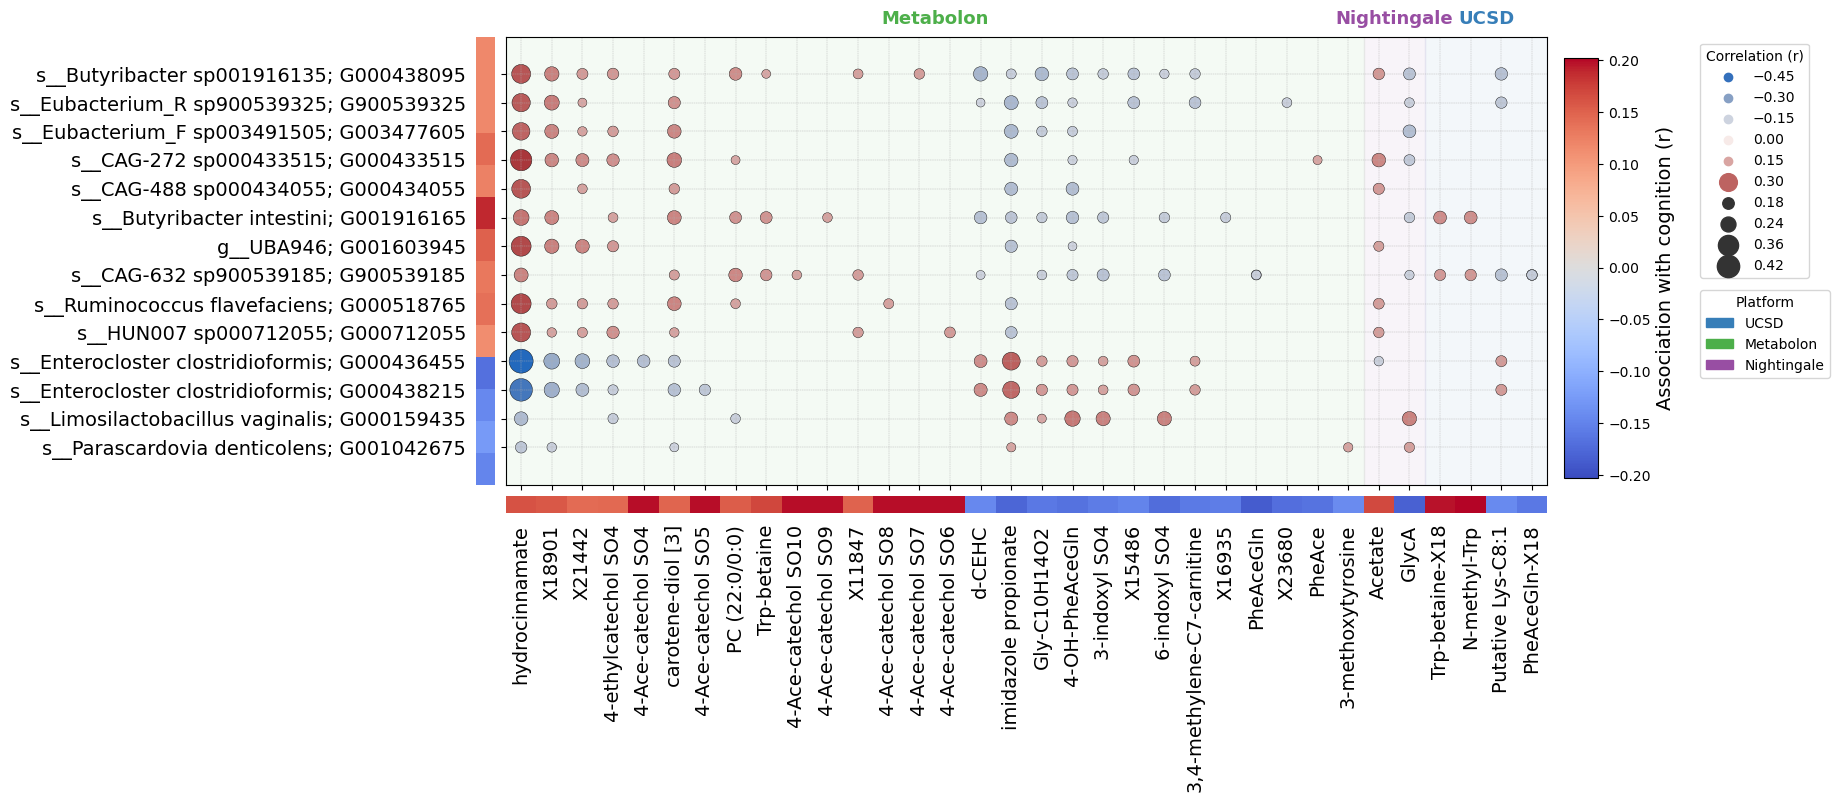

In [99]:
platform_palette = {
    # 'Baker': '#E41A1C',
    'UCSD': '#377EB8',
    'Metabolon': '#4DAF4A',
    'Nightingale': '#984EA3',
}

plot_corr(df_merged, 'Metabolite', figsize=(17, 7))

In [428]:
df_plot_merged[df_plot_merged['q_value'] < .05]

,microbe_w_tax,metabolite,microbe_metabolite_r,p_value,q_value,Platform,metag_moca_r,metab_moca_r,metag_moca_dir,metab_moca_dir,abbreviated_name
0,Enterocloster clostridioformis; G000436455,X3.phenylpropionate..hydrocinnamate.,-0.473374,1.647684e-29,3.939105e-24,Metabolon,-0.168940,0.162563,Negative,Positive,hydrocinnamate
1,Enterocloster clostridioformis; G000438215,X3.phenylpropionate..hydrocinnamate.,-0.428947,5.624231e-24,4.137172e-19,Metabolon,-0.144737,0.162563,Negative,Positive,hydrocinnamate
2,CAG-272 sp000433515; G000433515,X3.phenylpropionate..hydrocinnamate.,0.395413,2.607980e-20,7.634546e-16,Metabolon,0.142521,0.162563,Positive,Positive,hydrocinnamate
3,Ruminococcus flavefaciens; G000518765,X3.phenylpropionate..hydrocinnamate.,0.356045,1.650761e-16,1.271615e-12,Metabolon,0.137550,0.162563,Positive,Positive,hydrocinnamate
4,UBA946; G001603945,X3.phenylpropionate..hydrocinnamate.,0.355315,1.919935e-16,1.415930e-12,Metabolon,0.150918,0.162563,Positive,Positive,hydrocinnamate
...,...,...,...,...,...,...,...,...,...,...,...
202,Eubacterium_R sp900539325; G900539325,X.21442,0.147023,9.313752e-04,4.384140e-02,Metabolon,0.118160,0.142557,Positive,Positive,X21442
203,Parascardovia denticolens; G001042675,carotene.diol..3.,-0.146783,9.497619e-04,4.438139e-02,Metabolon,-0.148129,0.147827,Negative,Positive,carotene-diol [3]
204,Butyribacter sp001916135; G000438095,tryptophan.betaine,0.145790,1.029247e-03,4.670130e-02,Metabolon,0.117661,0.169598,Positive,Positive,Trp-betaine
205,UBA946; G001603945,X4.hydroxyphenylacetylglutamine,-0.145379,1.063962e-03,4.768366e-02,Metabolon,0.150918,-0.166917,Positive,Negative,4-OH-PheAceGln


In [383]:
df_plot

,microbe_w_tax,metabolite,metabolite_name,abbreviated_name,microbe_metabolite_r,p_value,q_value,Platform,metag_moca_r,metab_moca_r,metag_moca_dir,metab_moca_dir
23,Limosilactobacillus vaginalis; G000159435,X6.hydroxyindole.sulfate,6-hydroxyindole sulfate,6-indoxyl SO4,0.226958,2.610000e-07,0.000077,Metabolon,-0.126248,-0.170954,Negative,Negative
71,CAG-632 sp900539185; G900539185,X6.hydroxyindole.sulfate,6-hydroxyindole sulfate,6-indoxyl SO4,-0.187254,2.330000e-05,0.003341,Metabolon,0.132314,-0.170954,Positive,Negative
108,Butyribacter intestini; G001916165,X6.hydroxyindole.sulfate,6-hydroxyindole sulfate,6-indoxyl SO4,-0.167109,1.640330e-04,0.013920,Metabolon,0.188355,-0.170954,Positive,Negative
150,Butyribacter sp001916135; G000438095,X6.hydroxyindole.sulfate,6-hydroxyindole sulfate,6-indoxyl SO4,-0.152882,5.733270e-04,0.032164,Metabolon,0.117661,-0.170954,Positive,Negative
14,Limosilactobacillus vaginalis; G000159435,X4.hydroxyphenylacetylglutamine,4-hydroxyphenylacetylglutamine,4-OH-PheAceGln,0.250589,1.180000e-08,0.000005,Metabolon,-0.126248,-0.166917,Negative,Negative
...,...,...,...,...,...,...,...,...,...,...,...,...
88,CAG-488 sp000434055; G000434055,Acetate,Acetate,Acetate,0.177180,8.890000e-05,0.010362,Nightingale,0.123856,0.168725,Positive,Positive
99,Ruminococcus flavefaciens; G000518765,Acetate,Acetate,Acetate,0.170827,1.591940e-04,0.013966,Nightingale,0.137550,0.168725,Positive,Positive
114,HUN007 sp000712055; G000712055,Acetate,Acetate,Acetate,0.166575,2.324010e-04,0.017060,Nightingale,0.112654,0.168725,Positive,Positive
123,; G001603945,Acetate,Acetate,Acetate,0.161966,3.466400e-04,0.020919,Nightingale,0.150918,0.168725,Positive,Positive


In [380]:
df_plot_merged[df_plot_merged['abbreviated_name'] == '4-Ace-catechol SO5']

,microbe_w_tax,metabolite,microbe_metabolite_r,p_value,q_value,Platform,metag_moca_r,metab_moca_r,metag_moca_dir,metab_moca_dir,abbreviated_name
1261,Enterocloster clostridioformis; G000436455,X4.acetylcatechol.sulfate..1.,-0.198800,0.000007,0.001280,Metabolon,-0.168940,0.198411,Negative,Positive,4-Ace-catechol SO5
1268,Enterocloster clostridioformis; G000438215,X4.acetylcatechol.sulfate..1.,-0.179883,0.000049,0.005837,Metabolon,-0.144737,0.198411,Negative,Positive,4-Ace-catechol SO5
1275,HUN007 sp000712055; G000712055,X4.acetylcatechol.sulfate..1.,0.172214,0.000102,0.009983,Metabolon,0.112654,0.198411,Positive,Positive,4-Ace-catechol SO5
1282,Butyribacter sp001916135; G000438095,X4.acetylcatechol.sulfate..1.,0.167798,0.000154,0.013324,Metabolon,0.117661,0.198411,Positive,Positive,4-Ace-catechol SO5
1289,Ruminococcus flavefaciens; G000518765,X4.acetylcatechol.sulfate..1.,0.160233,0.000304,0.021219,Metabolon,0.137550,0.198411,Positive,Positive,4-Ace-catechol SO5
1296,Butyribacter intestini; G001916165,X4.acetylcatechol.sulfate..1.,0.156349,0.000427,0.026570,Metabolon,0.188355,0.198411,Positive,Positive,4-Ace-catechol SO5
1303,CAG-632 sp900539185; G900539185,X4.acetylcatechol.sulfate..1.,0.154490,0.000500,0.029457,Metabolon,0.132314,0.198411,Positive,Positive,4-Ace-catechol SO5


In [378]:
df_plot_merged['abbreviated_name'].value_counts()

hydrocinnamate                196
imidazole propionate          169
carotene-diol [3]             144
X18901                        121
4-OH-PheAceGln                121
X21442                        100
4-ethylcatechol SO4           100
Gly-C10H14O2                   64
GlycA                          64
Acetate                        49
3-indoxyl SO4                  36
PC (22:0/0:0)                  36
d-CEHC                         36
X15486                         25
Putative Lys-C8:1              25
3,4-methylene-C7-carnitine     16
6-indoxyl SO4                  16
X11847                          9
Trp-betaine                     9
4-Ace-catechol SO9              7
4-Ace-catechol SO10             7
4-Ace-catechol SO5              7
4-Ace-catechol SO8              7
4-Ace-catechol SO7              7
4-Ace-catechol SO6              7
4-Ace-catechol SO4              7
N-methyl-Trp                    4
Trp-betaine-X18                 4
PheAceGln-X18                   2
X16935        

In [59]:
df_merged.to_csv('microbe_metabolite_results.csv')

## Calculate log-ratios and test with diagnostic groups and diet

In [60]:
# Define OGUs negative and positivley associated with MOCA
bottom_otus = ['G000436455', 'G000438215', 'G000159435', 'G001042675']

top_otus = ['G900539185', 'G000438095', 'G900547795',
       'G001916165', 'G000155855', 'G900539325', 'G000433515',
       'G000518765', 'G000712055', 'G000421005', 'G003477605', 'G900103835', 'G001603945', 'G000434055', 'G000179635', 'G900095865']

In [61]:
# Sum top and bottom microbes
top_sum = non_clr[top_otus].sum(axis=1)
bottom_sum = non_clr[bottom_otus].sum(axis=1)

In [62]:
# Compute log ratio
md[f'moca_log_ratios'] = np.log(top_sum/bottom_sum)

In [63]:
def plot_groups(df, test_col, group_col, title, ylabel, palette, output, order=None, y=.05):

    jitter_value = 0.1  # Jitter for the stripplot
    
    ft_test = df.dropna(subset=[test_col, group_col])
    groups = ft_test[group_col].unique()
    data = [ft_test[ft_test[group_col] == group][test_col] for group in groups]
    
    if len(groups) == 2:
        kw_statistic, kw_pvalue = mannwhitneyu(*data)
        test_name = 'U'
    else:
        kw_statistic, kw_pvalue = kruskal(*data)
        test_name = 'KW'

    # Plotting
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.boxplot(x=group_col, y=test_col, data=ft_test, width=0.5, order=order, palette=palette)
    sns.stripplot(x=group_col, y=test_col, data=ft_test, color='k', size=5, jitter=jitter_value, alpha=0.5, edgecolor='gray', linewidth=0.5, ax=ax, order=order)

    plt.title(title, fontsize=14)
    p_value_text = f"< .001" if kw_pvalue < 0.001 else f"= {kw_pvalue:.2f}".lstrip('0') if kw_pvalue < 0.01 else f"= {kw_pvalue:.2f}".lstrip('0')
    plt.text(0.5, y, f'{test_name}: {kw_statistic:.1f}, \n $\mathit{{P}}$ value: {kw_pvalue:.2e}', 
             ha='center', va='top', fontsize=11, transform=ax.transAxes)

    plt.xlabel("", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)

    # Setting the linewidth and color of the axes spines
    for spine in ax.spines.values():
        spine.set_linewidth(1)
        spine.set_edgecolor('black')

    plt.tight_layout()
    plt.savefig(output, dpi=600)
    plt.show()

    

In [64]:
md = md.replace(np.inf, np.nan)

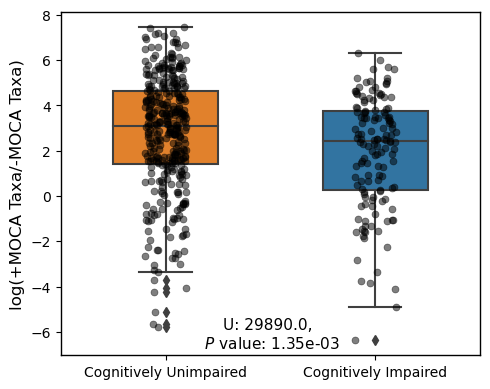

In [65]:
palette = {'Cognitively Unimpaired': '#ff7f0e', 'Cognitively Impaired': '#1f77b4'}

plot_groups(md, 'moca_log_ratios', 'Diagonsis', '', "log(+MOCA Taxa/-MOCA Taxa)", palette, '../figures/diagnosis_log_ratio.png', order=None, y=.11)

In [66]:
md['SEX'].value_counts()

2.0    313
1.0    193
Name: SEX, dtype: int64

In [67]:
males = md[md['SEX'] == 1]

In [68]:
females = md[md['SEX'] == 2]

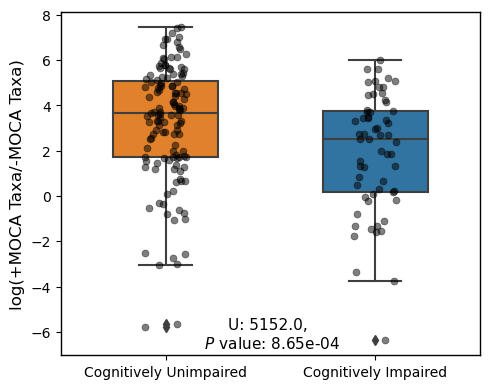

In [69]:
plot_groups(males, 'moca_log_ratios', 'Diagonsis', '', "log(+MOCA Taxa/-MOCA Taxa)", palette, '../figures/males_diagnosis_log_ratio.png', order=None, y=.11)

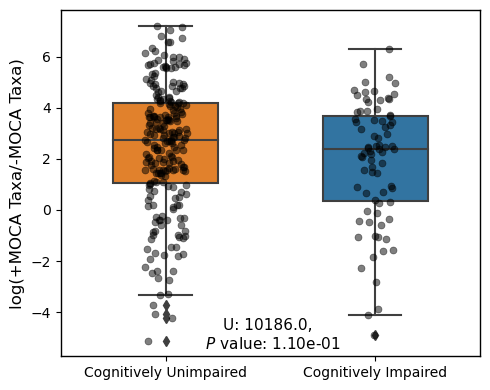

In [70]:
plot_groups(females, 'moca_log_ratios', 'Diagonsis', '', "log(+MOCA Taxa/-MOCA Taxa)", palette, '../figures/females_diagnosis_log_ratio.png', order=None, y=.11)

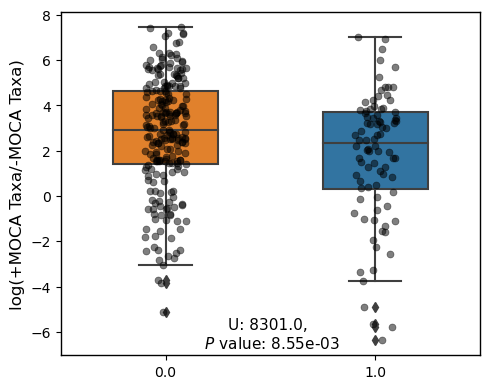

In [71]:
palette = {0: '#ff7f0e', 1: '#1f77b4'}

outcome = 'Hippocampal Atrophy'
plot_groups(md, 'moca_log_ratios', outcome, '', "log(+MOCA Taxa/-MOCA Taxa)", palette, f'../figures/{outcome}_log_ratio.png', order=None, y=.11)

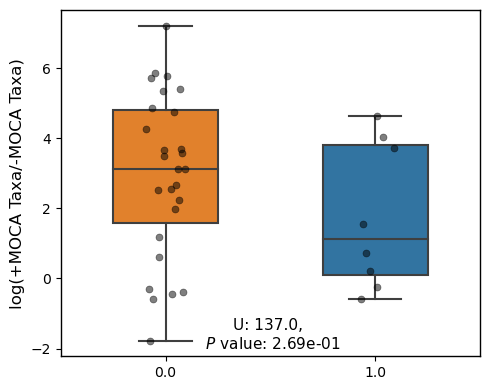

In [72]:
palette = {0: '#ff7f0e', 1: '#1f77b4'}

outcome = 'Tau CSF'
plot_groups(md, 'moca_log_ratios', outcome, '', "log(+MOCA Taxa/-MOCA Taxa)", palette, f'../figures/{outcome}_log_ratio.png', order=None, y=.11)

In [140]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import seaborn as sns

def plot_corr(df, sex, x, y, group=None): 
    print(x)
    df[x] = df[x].replace({'unknown' : np.nan})
    df = df.copy().dropna(subset=[x, y])
    df[x] = df[x].astype(float)
    # Perform Pearson correlation
    correlation, p_value = spearmanr(df[x], df[y])
    
    if p_value < .05:
        # Plot the scatter plot with a line of best fit for each HIV group
        plt.figure(figsize=(7, 3))
        if group is not None:
            sns.lmplot(x=x, y=y, hue=group, data=df, scatter_kws={'s': 30}, height=5,legend=False)
        else:
            sns.lmplot(x=x, y=y, data=df, scatter_kws={'s': 30}, height=4, legend=False)

        # Add text to show Pearson correlation coefficient on the plot
        plt.text(0.05, 0.05, f'Spearman r = {correlation:.2f}, \nP-value: {p_value:.2e}', ha='left', va='center', 
                 fontsize=12, transform=plt.gca().transAxes)

        # Customize the appearance of the spines (add box including top and right)
        ax = plt.gca()
        # Make the top and right spines visible
        ax.spines['top'].set_visible(True)
        ax.spines['right'].set_visible(True)

        # Label the axes and set a title
        plt.xlabel("log(+MoCA Taxa/-MoCA Taxa)", size=14)
        plt.ylabel('MoCA', size=14)
        plt.title(f'', size=14)

#         # Adjust legend title and location
#         plt.legend(title=f'{group}', loc='best')  # Set title for the legend

        # Adjust layout and display the plot
        plt.tight_layout()
        plt.savefig(f'../figures/{sex}_{x}_{y}_{group}_correlation.png', dpi = 300, bbox_inches='tight', pad_inches=0.1)
        plt.show()
    
    else:
        print(f"{x} not significant: Spearman correlation: {correlation:.2f}, P-value: {p_value:.3f}")

moca_log_ratios


<Figure size 700x300 with 0 Axes>

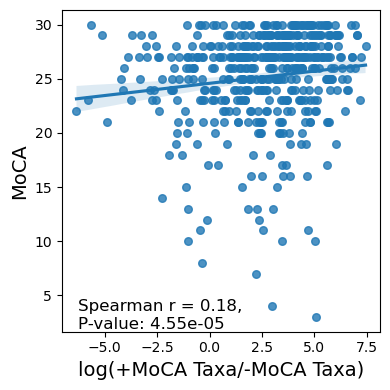

In [141]:
plot_corr(md, 'All', 'moca_log_ratios', 'MOCA', group=None)

moca_log_ratios


/tmp/ipykernel_248968/2619691229.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[x] = df[x].replace({'unknown' : np.nan})


<Figure size 700x300 with 0 Axes>

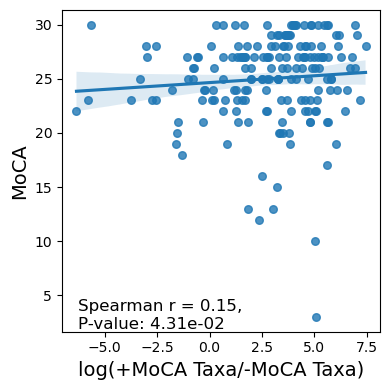

In [142]:
plot_corr(males, 'Males', 'moca_log_ratios', 'MOCA', group=None)

moca_log_ratios


/tmp/ipykernel_248968/2619691229.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[x] = df[x].replace({'unknown' : np.nan})


<Figure size 700x300 with 0 Axes>

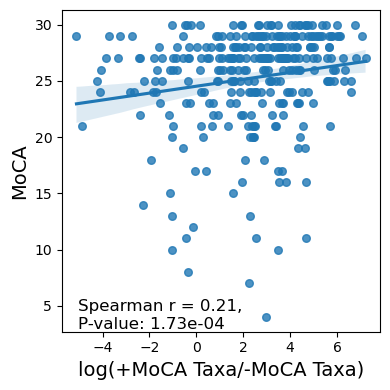

In [143]:
plot_corr(females, 'Females', 'moca_log_ratios', 'MOCA', group=None)

In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import seaborn as sns

def plot_corr(df, sex, x, y, group=None): 
    print(x)
    df[x] = df[x].replace({'unknown' : np.nan})
    df = df.copy().dropna(subset=[x, y])
    df[x] = df[x].astype(float)
    # Perform Pearson correlation
    correlation, p_value = spearmanr(df[x], df[y])
    
    if p_value < .05:
        # Plot the scatter plot with a line of best fit for each HIV group
        plt.figure(figsize=(7, 3))
        if group is not None:
            sns.lmplot(x=x, y=y, hue=group, data=df, scatter_kws={'s': 30}, height=5,legend=False)
        else:
            sns.lmplot(x=x, y=y, data=df, scatter_kws={'s': 30}, height=4, legend=False)

        # Add text to show Pearson correlation coefficient on the plot
        plt.text(0.05, .93, f'Spearman r = {correlation:.2f}, \nP-value: {p_value:.2e}', ha='left', va='center', 
                 fontsize=12, transform=plt.gca().transAxes)

        # Customize the appearance of the spines (add box including top and right)
        ax = plt.gca()
        # Make the top and right spines visible
        ax.spines['top'].set_visible(True)
        ax.spines['right'].set_visible(True)

        # Label the axes and set a title
        plt.xlabel("log(+MoCA Taxa/-MoCA Taxa)", size=14)
        plt.ylabel(y, size=14)
        plt.title(f'', size=14)

#         # Adjust legend title and location
#         plt.legend(title=f'{group}', loc='best')  # Set title for the legend

        # Adjust layout and display the plot
        plt.tight_layout()
        plt.savefig(f'../figures/{sex}_{x}_{y}_{group}_correlation.png', dpi = 300, bbox_inches='tight', pad_inches=0.1)
        plt.show()
    
    else:
        print(f"{x} not significant: Spearman correlation: {correlation:.2f}, P-value: {p_value:.3f}")

moca_log_ratios


<Figure size 700x300 with 0 Axes>

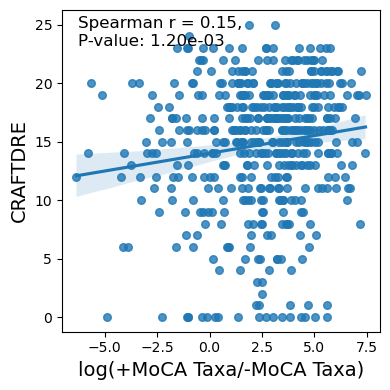

In [149]:
plot_corr(md, 'CRAFTDRE', 'moca_log_ratios', 'CRAFTDRE', group=None)

moca_log_ratios


<Figure size 700x300 with 0 Axes>

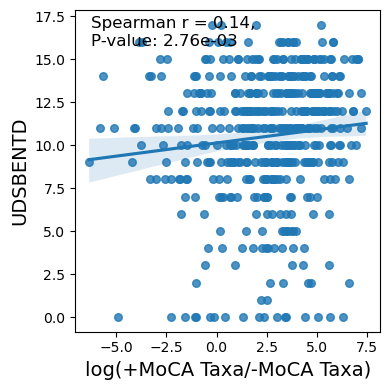

In [150]:
plot_corr(md, 'UDSBENTD', 'moca_log_ratios', 'UDSBENTD', group=None)

In [131]:
md.columns

Index(['Diagonsis', 'fiber', 'Amyloid PET', 'CRAFTDRE', 'Amyloid CSF',
       'Hippocampal Atrophy', 'Tau PET', 'Tau CSF', 'MOCA', 'UDSBENTD',
       'Depression', 'Anxiety', 'Antidepressants', 'pTau181', 'pTau217', 'NFL',
       'GFAP', 'Abeta40', 'Abeta42', 'ADI_NAT', 'ADI_STATE', 'site', 'NACCAGE',
       'SEX', 'NACCBMI', 'fasting', 'HEI2015Score', 'HEI2015_Fruit',
       'HEI2015_Whole_Fruit', 'HEI2015_Veg', 'HEI2015_Greens_Beans',
       'HEI2015_Whole_Grains', 'HEI2015_Dairy', 'HEI2015_Protein_Foods',
       'HEI2015_SeaFoods_PlantProteins', 'HEI2015_Fatty_Acids',
       'HEI2015_Refined_Grains', 'HEI2015_Sodium', 'HEI2015_Saturated_Fat',
       'HEI2015_Added_Sugars', 'moca_log_ratios'],
      dtype='object')

In [63]:
hei = md.filter(like='HEI')

In [64]:
food = pd.read_csv('../data/foodomics_adrc_fecal_set_one.csv', dtype={'sample_name': str}).set_index('sample_name')

In [65]:
food_clr = multiplicative_clr(food.clip(lower=0))

In [66]:
diet = pd.merge(hei, food_clr, on='sample_name', how='outer')

In [67]:
# diet['fiber'] = md['fiber']

In [68]:
diet_resid = residualize(diet, covars)

In [69]:
diet_resid['moca_log_ratios'] = md['moca_log_ratios']

In [70]:
diet_resid['metabolite_pc1'] = pd.read_csv('../output_files/sig_metabolites_joint_rpca.csv', dtype={'Unnamed: 0': str}).set_index('Unnamed: 0')['PC1']

diet_resid['metabolite_pc1'] = diet_resid['metabolite_pc1']*-1

In [71]:
# Collect results for all HEI columns
results = []

for hei in diet_resid.drop(columns=['moca_log_ratios', 'metabolite_pc1']).columns:
    sub = diet_resid[[hei, 'metabolite_pc1', 'moca_log_ratios']].dropna()
    if len(sub) < 3:  # skip tiny n
        continue
    metag_r, metag_p = spearmanr(sub[hei], sub['moca_log_ratios'])
    metab_r, metab_p = spearmanr(sub[hei], sub['metabolite_pc1'])
    results.append({
        'variable': hei,
        'n': len(sub),
        'metag_r': metag_r,
        'metag_p': metag_p,
        'metab_r': metab_r,
        'metab_p': metab_p,
    })
    

diet_df = pd.DataFrame(results)

# One FDR correction across all tests
diet_df['metag_q'] = multipletests(diet_df['metag_p'], method='fdr_bh')[1]
diet_df['metab_q'] = multipletests(diet_df['metab_p'], method='fdr_bh')[1]

In [72]:
diet_df = diet_df[(diet_df['metag_q'] < .05) | (diet_df['metab_q'] < .05)]

In [73]:
diet_df = diet_df.set_index('variable')

In [95]:
diet_resid

,HEI2015Score,HEI2015_Fruit,HEI2015_Whole_Fruit,HEI2015_Veg,HEI2015_Greens_Beans,HEI2015_Whole_Grains,HEI2015_Dairy,HEI2015_Protein_Foods,HEI2015_SeaFoods_PlantProteins,HEI2015_Fatty_Acids,...,Tomatidine,Tyramine,gamma-Linolenic acid,hesperidin,methionine,p-Coumaric acid,secoisolariciresinol diglucoside,tryptophan,moca_log_ratios,metabolite_pc1
sample_name,,,,,,,,,,,,,,,,,,,,,
15448.42368322,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.734234,-0.048114
15448.42209258,6.660070,0.537598,0.125645,0.394698,0.708541,-0.955087,3.291402,0.306331,0.496612,1.926130,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.085275,0.088659
15448.42385333,-21.249091,-1.343575,-0.810170,-1.787329,-3.401444,-3.487451,4.283385,-0.547594,-4.048633,-5.221648,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.489425,-0.072382
15448.42372244,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.273748,-0.042050
15448.42326795,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.080153,-0.029878
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15448.0042121186,-9.680628,-0.600499,0.275134,0.772478,1.193552,-3.977993,-1.839832,0.386248,0.593198,1.619501,...,-0.46034,-0.596151,-1.988737,0.26943,2.016845,1.134819,0.295603,1.094279,6.950815,0.121557
15448.42556374,-1.200520,1.507588,0.812975,0.947758,1.618213,-1.851170,0.723041,0.437536,0.813596,-1.531449,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-5.796203,-0.106567
15448.42593049,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.200547,0.085276


In [75]:
diet_df['summed_r'] = diet_df['metag_r'] + diet_df['metab_r']

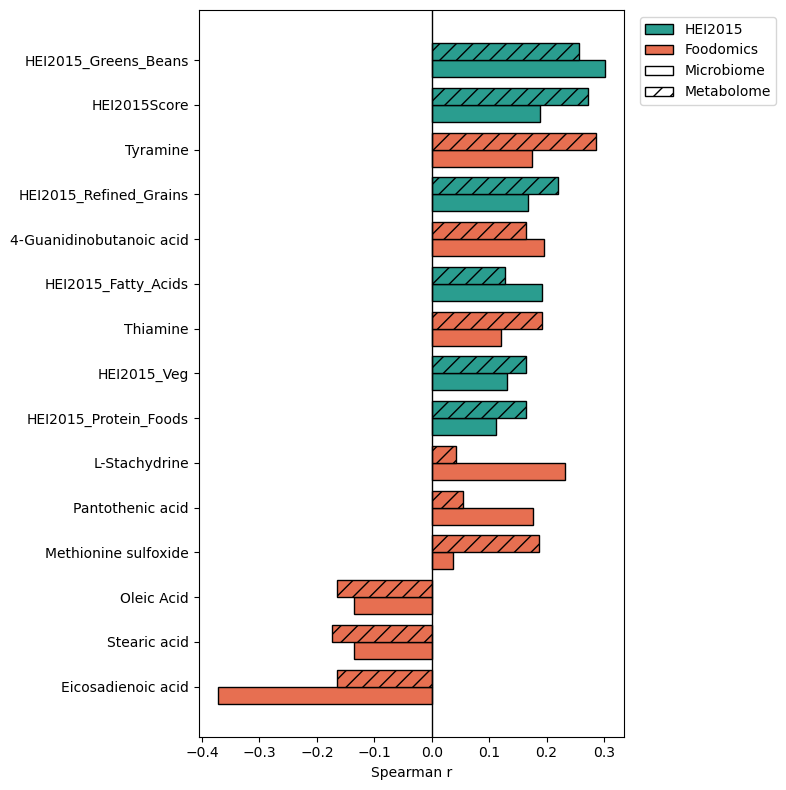

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Start from your diet_df
df_plot = diet_df.copy()

# Add category
df_plot['category'] = df_plot.index.to_series().apply(
    lambda x: 'HEI2015' if x.startswith('HEI2015') else 'Foodomics'
)

# Reset index so feature names are a column
df_plot = df_plot.reset_index().rename(columns={'variable': 'feature'})

# Sort by combined effect
df_plot = df_plot.sort_values('summed_r')

# Colors for diet category
color_map = {
    'HEI2015': '#2A9D8F',
    'Foodomics': '#E76F51'
}

# Bar positions
y = np.arange(len(df_plot))
bar_h = 0.38

fig, ax = plt.subplots(figsize=(8, 8))

# Draw bars manually
for i, row in df_plot.iterrows():
    pos = df_plot.index.get_loc(i)
    color = color_map[row['category']]
    
    # Microbiome bar
    ax.barh(
        y[pos] - bar_h/2,
        row['metag_r'],
        height=bar_h,
        color=color,
        edgecolor='black',
        linewidth=1
    )
    
    # Metabolome bar
    ax.barh(
        y[pos] + bar_h/2,
        row['metab_r'],
        height=bar_h,
        color=color,
        edgecolor='black',
        linewidth=1,
        hatch='//'
    )

# Axis formatting
ax.set_yticks(y)
ax.set_yticklabels(df_plot['feature'])
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Spearman r')
ax.set_ylabel('')
ax.set_title('')

# Custom legend
legend_elements = [
    Patch(facecolor='#2A9D8F', edgecolor='black', label='HEI2015'),
    Patch(facecolor='#E76F51', edgecolor='black', label='Foodomics'),
    Patch(facecolor='white', edgecolor='black', label='Microbiome'),
    Patch(facecolor='white', edgecolor='black', hatch='//', label='Metabolome')
]

ax.legend(handles=legend_elements, bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig('../figures/diet_multiomics.png', dpi=300, bbox_inches='tight')
plt.show()

In [77]:
from scipy.stats import rankdata
md['greens_rank'] = rankdata(md['HEI2015_Greens_Beans'])

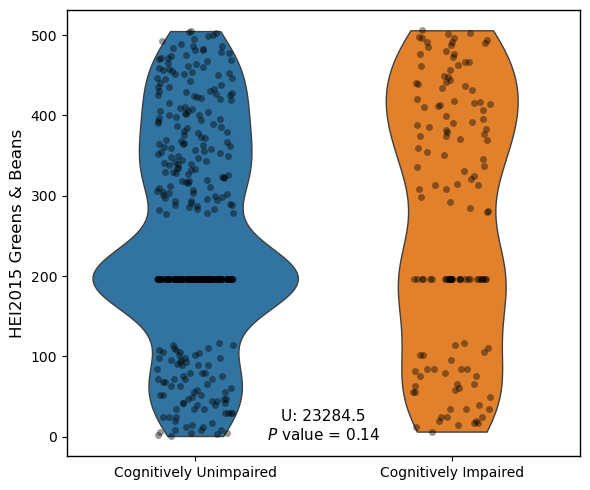

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, kruskal

test_col = 'greens_rank'
group_col = 'Diagonsis'

ft_test = md.dropna(subset=[test_col, group_col])
groups = ft_test[group_col].unique()
data = [ft_test[ft_test[group_col] == group][test_col] for group in groups]

if len(groups) == 2:
    kw_statistic, kw_pvalue = mannwhitneyu(*data)
    test_name = 'U'
else:
    kw_statistic, kw_pvalue = kruskal(*data)
    test_name = 'KW'

fig, ax = plt.subplots(figsize=(6, 5))

sns.violinplot(
    data=ft_test,
    x=group_col,
    y=test_col,
    inner=None,
    cut=0,
    linewidth=1,
    ax=ax
)

sns.stripplot(
    data=ft_test,
    x=group_col,
    y=test_col,
    color='black',
    alpha=0.4,
    jitter=0.15,
    ax=ax
)

p_value_text = (
    "< .001" if kw_pvalue < 0.001
    else f"= {kw_pvalue:.3f}".lstrip('0') if kw_pvalue < 0.01
    else f"= {kw_pvalue:.2f}".lstrip('0')
)

ax.text(
    0.5, 0.03,
    f'{test_name}: {kw_statistic:.1f}\n$\\mathit{{P}}$ value {p_value_text}',
    ha='center',
    va='bottom',
    fontsize=11,
    transform=ax.transAxes
)

ax.set_xlabel("")
ax.set_ylabel("HEI2015 Greens & Beans", fontsize=12)

for spine in ax.spines.values():
    spine.set_linewidth(1)
    spine.set_edgecolor('black')

fig.tight_layout()
fig.savefig("../figures/greens_beans_by_diagnosis.png", dpi=600)
plt.show()

In [79]:
md['HEI2015_Greens_Beans'].skew()

-1.101739114713432

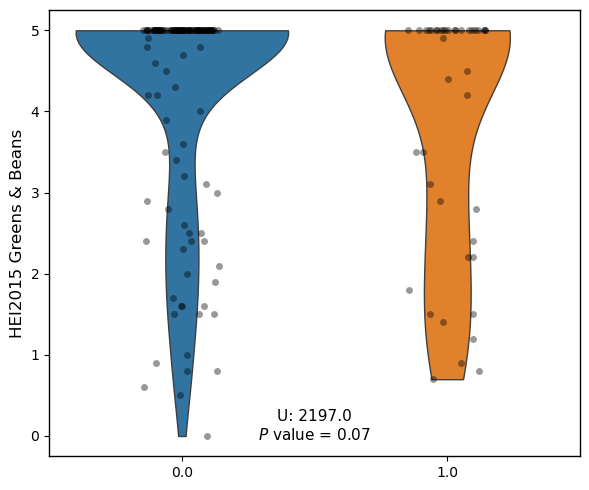

In [80]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, kruskal

test_col = 'HEI2015_Greens_Beans'
group_col = 'Hippocampal Atrophy'

ft_test = md.dropna(subset=[test_col, group_col])
groups = ft_test[group_col].unique()
data = [ft_test[ft_test[group_col] == group][test_col] for group in groups]

if len(groups) == 2:
    kw_statistic, kw_pvalue = mannwhitneyu(*data)
    test_name = 'U'
else:
    kw_statistic, kw_pvalue = kruskal(*data)
    test_name = 'KW'

fig, ax = plt.subplots(figsize=(6, 5))

sns.violinplot(
    data=ft_test,
    x=group_col,
    y=test_col,
    inner=None,
    cut=0,
    linewidth=1,
    ax=ax
)

sns.stripplot(
    data=ft_test,
    x=group_col,
    y=test_col,
    color='black',
    alpha=0.4,
    jitter=0.15,
    ax=ax
)

p_value_text = (
    "< .001" if kw_pvalue < 0.001
    else f"= {kw_pvalue:.3f}".lstrip('0') if kw_pvalue < 0.01
    else f"= {kw_pvalue:.2f}".lstrip('0')
)

ax.text(
    0.5, 0.03,
    f'{test_name}: {kw_statistic:.1f}\n$\\mathit{{P}}$ value {p_value_text}',
    ha='center',
    va='bottom',
    fontsize=11,
    transform=ax.transAxes
)

ax.set_xlabel("")
ax.set_ylabel("HEI2015 Greens & Beans", fontsize=12)

for spine in ax.spines.values():
    spine.set_linewidth(1)
    spine.set_edgecolor('black')

fig.tight_layout()
fig.savefig("../figures/greens_beans_by_Hippocampal_Atrophy.png", dpi=600)
plt.show()

In [118]:
md['Eicosadienoic_acid'] = food_clr['Eicosadienoic acid']

In [138]:
food_clr.columns

Index(['4-Guanidinobutanoic acid', 'Amoxicillin', 'Capsaicin', 'Carnitine',
       'Cinnamic acid', 'Daidzein', 'Deoxycarnitine', 'Eicosadienoic acid',
       'Glutamic acid', 'Histamine', 'Hypaphorine', 'Isoleucine', 'Isomalt',
       'L-Stachydrine', 'Lactose', 'Methionine sulfoxide', 'Oleic Acid',
       'Pantothenic acid', 'Phenylethylamine', 'Piperine', 'Quercetin',
       'Sinapine', 'Stearic acid', 'Sulforaphane', 'Thiamine', 'Tomatidine',
       'Tyramine', 'gamma-Linolenic acid', 'hesperidin', 'methionine',
       'p-Coumaric acid', 'secoisolariciresinol diglucoside', 'tryptophan'],
      dtype='object')

In [139]:
md['Eicosadienoic_acid'] = food_clr['Eicosadienoic acid']
md['Stearic_acid'] = food_clr['Stearic acid']
md['Oleic_Acid'] = food_clr['Oleic Acid']

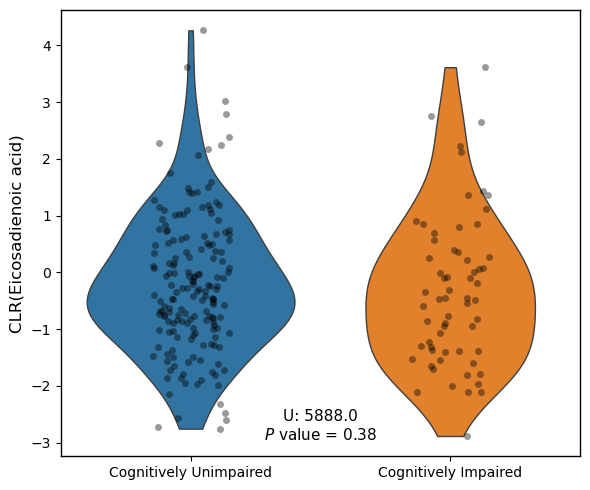

In [141]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, kruskal

test_col = 'Oleic_Acid'
group_col = 'Diagonsis'

ft_test = md.dropna(subset=[test_col, group_col])
groups = ft_test[group_col].unique()
data = [ft_test[ft_test[group_col] == group][test_col] for group in groups]

if len(groups) == 2:
    kw_statistic, kw_pvalue = mannwhitneyu(*data)
    test_name = 'U'
else:
    kw_statistic, kw_pvalue = kruskal(*data)
    test_name = 'KW'

fig, ax = plt.subplots(figsize=(6, 5))

sns.violinplot(
    data=ft_test,
    x=group_col,
    y=test_col,
    inner=None,
    cut=0,
    linewidth=1,
    ax=ax
)

sns.stripplot(
    data=ft_test,
    x=group_col,
    y=test_col,
    color='black',
    alpha=0.4,
    jitter=0.15,
    ax=ax
)

p_value_text = (
    "< .001" if kw_pvalue < 0.001
    else f"= {kw_pvalue:.3f}".lstrip('0') if kw_pvalue < 0.01
    else f"= {kw_pvalue:.2f}".lstrip('0')
)

ax.text(
    0.5, 0.03,
    f'{test_name}: {kw_statistic:.1f}\n$\\mathit{{P}}$ value {p_value_text}',
    ha='center',
    va='bottom',
    fontsize=11,
    transform=ax.transAxes
)

ax.set_xlabel("")
ax.set_ylabel("CLR(Eicosadienoic acid)", fontsize=12)

for spine in ax.spines.values():
    spine.set_linewidth(1)
    spine.set_edgecolor('black')

fig.tight_layout()
fig.savefig("../figures/Eicosadienoic_acid_by_diagnosis.png", dpi=600)
plt.show()

In [120]:
md[md['Diagonsis'] == 'Cognitively Impaired']['Eicosadienoic acid'].mean()

-0.18712285312446408

In [121]:
md[md['Diagonsis'] == 'Cognitively Unimpaired']['Eicosadienoic acid'].mean()

0.11114369141308712

In [122]:
# plot_groups(md, 'moca_log_ratios', 'Diagonsis', '', "log(+MOCA Taxa/-MOCA Taxa)", palette, '../figures/diagnosis_log_ratio.png', order=None, y=.11)

In [123]:
diet_resid_filt = diet_resid[df_plot['feature']]

In [124]:
diet_resid_filt['moca_res'] = cog_resid

/tmp/ipykernel_239798/3244175044.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diet_resid_filt['moca_res'] = cog_resid


In [125]:
# Collect results for all HEI columns
results = []

for hei in diet_resid_filt.drop(columns=['moca_res']).columns:
    sub = diet_resid_filt[[hei, 'moca_res']].dropna()
    if len(sub) < 3:  # skip tiny n
        continue
    moca_r, moca_p = spearmanr(sub[hei], sub['moca_res'])
    results.append({
        'variable': hei,
        'n': len(sub),
        'moca_r': moca_r,
        'moca_p': moca_p
    })
    

diet_moca_df = pd.DataFrame(results)

# One FDR correction across all tests
diet_moca_df['moca_p'] = multipletests(diet_moca_df['moca_p'], method='fdr_bh')[1]

In [126]:
diet_moca_df[diet_moca_df['moca_p'] < .05]

,variable,n,moca_r,moca_p
10,4-Guanidinobutanoic acid,230,0.19776,0.038846


In [127]:
diet_moca_df

,variable,n,moca_r,moca_p
0,Eicosadienoic acid,230,0.080308,0.675093
1,Stearic acid,230,-0.144729,0.211482
2,Oleic Acid,230,-0.031349,0.886301
3,Methionine sulfoxide,230,0.030082,0.886301
4,Pantothenic acid,230,0.056841,0.732885
5,L-Stachydrine,230,0.033770,0.886301
6,HEI2015_Protein_Foods,268,0.056738,0.732885
7,HEI2015_Veg,268,-0.077868,0.675093
8,Thiamine,230,0.020131,0.951721
9,HEI2015_Fatty_Acids,268,-0.004693,0.969342


In [128]:
# Collect results for all HEI columns
results = []

for hei in diet_resid.drop(columns=['moca_log_ratios','metabolite_pc1']).columns:
    sub = diet_resid[[hei, 'metabolite_pc1']].dropna()
    if len(sub) < 3:  # skip tiny n
        continue
    r, p = spearmanr(sub[hei], sub['metabolite_pc1'])
    results.append({
        'hei': hei,
        'n': len(sub),
        'moca_r': r,
        'moca_p': p
    })

hei_df = pd.DataFrame(results)

# One FDR correction across all tests
hei_df['moca_q'] = multipletests(hei_df['moca_p'], method='fdr_bh')[1]

hei_df = hei_df.set_index('hei')

# Filter significant results
hei_df = hei_df[hei_df['moca_q'] < 0.05]

In [129]:
hei_df

,n,moca_r,moca_p,moca_q
hei,,,,
HEI2015Score,276,0.265496,0.000008,0.000196
HEI2015_Veg,276,0.164488,0.006163,0.036605
HEI2015_Greens_Beans,276,0.252287,0.000022,0.000348
HEI2015_Protein_Foods,276,0.164277,0.006231,0.036605
HEI2015_Refined_Grains,276,0.217936,0.000264,0.003104
4-Guanidinobutanoic acid,237,0.164478,0.011212,0.048677
Eicosadienoic acid,237,-0.162157,0.012428,0.048677
Methionine sulfoxide,237,0.184979,0.004272,0.033462
Oleic Acid,237,-0.164037,0.011435,0.048677


In [130]:
# # Plot HEI corr results

# # Create category column
# df_plot = diet_df.sort_values('moca_r').copy()

# df_plot['category'] = df_plot.index.to_series().apply(
#     lambda x: 'HEI2015' if x.startswith('HEI2015') else 'Foodomics'
# )

# # Define colors manually (so it's consistent)
# palette = {
#     'HEI2015': '#2A9D8F',     # blue
#     'Foodomics': '#E76F51'    # orange
# }

# # Plot
# plt.figure(figsize=(8,5))
# sns.barplot(
#     data=df_plot,
#     y=df_plot.index,
#     x='moca_r',
#     hue='category',
#     dodge=False,
#     palette=palette
# )


# plt.axvline(0, color='black', lw=1)
# plt.title('Associations Between HEI Components and Metabolites PC1')
# plt.xlabel('Spearman r')
# plt.ylabel('')
# plt.tight_layout()
# plt.savefig('../figures/diet_moca_metabolites_pc1.png', dpi = 300)
# plt.show()


## Serial Mediation Analysis

In [131]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

def _fit_paths(df, x, m1, m2, y, covariates=None):
    """
    Fits:
      (1) m1 ~ a1*x + covs
      (2) m2 ~ a2*x + d*m1 + covs
      (3) y  ~ cprime*x + b1*m1 + b2*m2 + covs

    Returns path coefficients and effects.
    """
    covariates = covariates or []
    cov_str = " + " + " + ".join(covariates) if covariates else ""

    # (1) m1 model
    mod1 = smf.ols(f"{m1} ~ {x}{cov_str}", data=df).fit()
    a1 = mod1.params[x]

    # (2) m2 model
    mod2 = smf.ols(f"{m2} ~ {x} + {m1}{cov_str}", data=df).fit()
    a2 = mod2.params[x]
    d  = mod2.params[m1]

    # (3) y model
    mod3 = smf.ols(f"{y} ~ {x} + {m1} + {m2}{cov_str}", data=df).fit()
    cprime = mod3.params[x]
    b1 = mod3.params[m1]
    b2 = mod3.params[m2]

    # Total effect model: y ~ x + covs
    mod_tot = smf.ols(f"{y} ~ {x}{cov_str}", data=df).fit()
    c_total = mod_tot.params[x]

    # Indirect effects
    ind_micro = a1 * b1               # X -> M1 -> Y
    ind_metab = a2 * b2               # X -> M2 -> Y
    ind_chain = a1 * d * b2           # X -> M1 -> M2 -> Y
    total_ind = ind_micro + ind_metab + ind_chain

    out = {
        "a1": a1, "a2": a2, "d": d, "b1": b1, "b2": b2,
        "cprime": cprime, "c_total": c_total,
        "ind_micro": ind_micro, "ind_metab": ind_metab, "ind_chain": ind_chain,
        "total_ind": total_ind,
        "models": {"m1": mod1, "m2": mod2, "y": mod3, "total": mod_tot}
    }
    return out


def serial_mediation_bootstrap(
    df, x, m1, m2, y, covariates=None,
    n_boot=5000, seed=0, dropna=True
):
    """
    Bootstrap CIs for serial mediation effects.
    """
    covariates = covariates or []

    cols = [x, m1, m2, y] + covariates
    d0 = df[cols].copy()
    if dropna:
        d0 = d0.dropna()

    # Point estimate on full data
    point = _fit_paths(d0, x, m1, m2, y, covariates=covariates)

    # Bootstrap
    rng = np.random.default_rng(seed)
    boot = {k: [] for k in ["a1","a2","d","b1","b2","cprime","c_total",
                           "ind_micro","ind_metab","ind_chain","total_ind"]}

    n = len(d0)
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        db = d0.iloc[idx]
        est = _fit_paths(db, x, m1, m2, y, covariates=covariates)
        for k in boot:
            boot[k].append(est[k])

    # Summarize into dataframe with percentile CIs
    def ci(arr, lo=2.5, hi=97.5):
        return np.percentile(arr, [lo, hi])

    rows = []
    for k, arr in boot.items():
        arr = np.asarray(arr)
        lo, hi = ci(arr)
        rows.append({
            "effect": k,
            "estimate": point[k],
            "ci_2.5": lo,
            "ci_97.5": hi
        })

    res = pd.DataFrame(rows).set_index("effect")

    # Add proportion mediated (using total effect c_total)
    c_total = point["c_total"]
    if c_total != 0:
        res.loc["prop_mediated_total_ind", ["estimate","ci_2.5","ci_97.5"]] = [
            point["total_ind"] / c_total,
            np.percentile(np.asarray(boot["total_ind"]) / np.asarray(boot["c_total"]), 2.5),
            np.percentile(np.asarray(boot["total_ind"]) / np.asarray(boot["c_total"]), 97.5),
        ]

    return point, res


In [132]:
md['metabolite_pc1'] = pd.read_csv('../output_files/sig_metabolites_joint_rpca.csv', dtype={'Unnamed: 0': str}).set_index('Unnamed: 0')['PC1']

In [133]:
# from scipy.stats import rankdata
# md['greens_rank'] = rankdata(md['HEI2015_Greens_Beans'])

In [134]:
md

,Diagonsis,fiber,Amyloid PET,CRAFTDRE,Amyloid CSF,Hippocampal Atrophy,Tau PET,Tau CSF,MOCA,UDSBENTD,...,HEI2015_Fatty_Acids,HEI2015_Refined_Grains,HEI2015_Sodium,HEI2015_Saturated_Fat,HEI2015_Added_Sugars,moca_log_ratios,greens_rank,Eicosadienoic acid,metabolite_pc1,Eicosadienoic_acid
sample_name,,,,,,,,,,,,,,,,,,,,,
15448.42368322,Cognitively Unimpaired,NaN,NaN,13.0,NaN,NaN,NaN,NaN,23.0,14.0,...,NaN,NaN,NaN,NaN,NaN,0.734234,352.0,NaN,0.048114,NaN
15448.42209258,Cognitively Unimpaired,39.856434,NaN,21.0,NaN,1.0,NaN,NaN,29.0,15.0,...,7.2,10.0,5.7,3.421491,9.186920,1.085275,197.0,NaN,-0.088659,NaN
15448.42385333,Cognitively Unimpaired,14.781425,NaN,17.0,0.0,0.0,NaN,0.0,27.0,13.0,...,0.3,9.6,3.9,0.000000,7.455456,3.489425,9.0,NaN,0.072382,NaN
15448.42372244,Cognitively Impaired,NaN,NaN,0.0,NaN,NaN,NaN,NaN,20.0,4.0,...,NaN,NaN,NaN,NaN,NaN,0.273748,407.0,NaN,0.042050,NaN
15448.42326795,Cognitively Unimpaired,NaN,0.0,14.0,NaN,0.0,0.0,NaN,24.0,10.0,...,NaN,NaN,NaN,NaN,NaN,6.080153,406.0,NaN,0.029878,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15448.0042121186,Cognitively Unimpaired,85.491783,NaN,17.0,NaN,NaN,NaN,NaN,26.0,10.0,...,6.4,0.0,2.6,7.242449,10.000000,6.950815,197.0,-0.53831,-0.121557,-0.53831
15448.42556374,Cognitively Unimpaired,31.642000,0.0,14.0,NaN,1.0,0.0,NaN,23.0,11.0,...,2.8,5.3,0.0,5.021415,9.820618,-5.796203,197.0,NaN,0.106567,NaN
15448.42593049,Cognitively Impaired,NaN,NaN,11.0,NaN,0.0,NaN,NaN,29.0,11.0,...,NaN,NaN,NaN,NaN,NaN,5.200547,285.0,NaN,-0.085276,NaN


In [135]:
# Define variables 
X  = "Eicosadienoic_acid"
M1 = "moca_log_ratios"
M2 = "metabolite_pc1"
Y  = 'MOCA'

covs = ["NACCAGE", "SEX", "site"]

point, results = serial_mediation_bootstrap(
    df=md, x=X, m1=M1, m2=M2, y=Y,
    covariates=covs,
    n_boot=5000, seed=42
)

print(results.loc[["ind_chain", "ind_micro", "ind_metab", "total_ind", "cprime", "c_total",
                   "prop_mediated_total_ind"]])


                         estimate    ci_2.5   ci_97.5
effect                                               
ind_chain               -0.091084 -0.219486 -0.008241
ind_micro               -0.272081 -0.552157 -0.013580
ind_metab               -0.024035 -0.141426  0.106402
total_ind               -0.387200 -0.684185 -0.103494
cprime                   0.779658  0.095013  1.405779
c_total                  0.392458 -0.210751  0.980984
prop_mediated_total_ind -0.986600 -9.565093  9.070244


In [136]:
results

,estimate,ci_2.5,ci_97.5
effect,,,
a1,-1.085884,-1.392524,-0.787028
a2,0.001655,-0.006079,0.008828
d,-0.005776,-0.009437,-0.002481
b1,0.250561,0.012103,0.491842
b2,-14.523042,-25.711894,-2.155308
cprime,0.779658,0.095013,1.405779
c_total,0.392458,-0.210751,0.980984
ind_micro,-0.272081,-0.552157,-0.013580
ind_metab,-0.024035,-0.141426,0.106402


In [129]:
# Define variables 
X  = "HEI2015_Greens_Beans"
M1 = "metabolite_pc1"
M2 = "moca_log_ratios"
Y  = 'MOCA'

covs = ["NACCAGE", "SEX", "site"]

point, results = serial_mediation_bootstrap(
    df=md, x=X, m1=M1, m2=M2, y=Y,
    covariates=covs,
    n_boot=5000, seed=42
)

print(results.loc[["ind_chain", "ind_micro", "ind_metab", "total_ind", "cprime", "c_total",
                   "prop_mediated_total_ind"]])


                          estimate     ci_2.5    ci_97.5
effect                                                  
ind_chain                 0.027766   0.000856   0.072282
ind_micro                 0.164825   0.050920   0.309184
ind_metab                 0.102217   0.004465   0.214273
total_ind                 0.294808   0.131267   0.486199
cprime                   -0.275141  -0.675889   0.144432
c_total                   0.019667  -0.372424   0.443861
prop_mediated_total_ind  14.989796 -20.424658  24.064958


In [130]:
results

,estimate,ci_2.5,ci_97.5
effect,,,
a1,-0.010533,-0.016595,-0.004658
a2,0.468457,0.245621,0.668033
d,-12.081636,-17.194262,-7.060516
b1,-15.648775,-26.457795,-6.185789
b2,0.218199,0.009346,0.436017
cprime,-0.275141,-0.675889,0.144432
c_total,0.019667,-0.372424,0.443861
ind_micro,0.164825,0.050920,0.309184
ind_metab,0.102217,0.004465,0.214273


In [531]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# ---------- helpers ----------
def fit_ols(df, formula):
    return smf.ols(formula, data=df).fit()

def partial_residual_xy(df, y, x, covariates):
    """
    Partial residual plot data for effect of x on y adjusting for covariates:
      y_res = residuals of y ~ covs
      x_res = residuals of x ~ covs
    Then plot y_res vs x_res.
    """
    cov_str = " + ".join(covariates)
    m_y = fit_ols(df, f"{y} ~ {cov_str}") if covariates else None
    m_x = fit_ols(df, f"{x} ~ {cov_str}") if covariates else None

    y_res = m_y.resid if m_y is not None else df[y] - df[y].mean()
    x_res = m_x.resid if m_x is not None else df[x] - df[x].mean()
    return x_res, y_res

def add_regline(ax, x, y):
    # simple regression line for plotting
    x = np.asarray(x)
    y = np.asarray(y)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]; y = y[mask]
    if len(x) < 3:
        return
    b = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, b[0]*xs + b[1])

def annotate_ci(ax, text, xy=(0.02, 0.98), fontsize=9):
    ax.text(xy[0], xy[1], text, transform=ax.transAxes,
            ha="left", va="top", fontsize=fontsize)

def plot_serial_mediation_figure(
    df,
    X, M1, M2, Y,
    covs=None,
    effects_table=None,  
    savepath=None
):
    covs = covs or []

    # subset & dropna
    cols = [X, M1, M2, Y] + covs
    d = df[cols].dropna().copy()

    # Fit path models (for plotting + arrow labels)
    cov_str = (" + " + " + ".join(covs)) if covs else ""

    mod_m1 = fit_ols(d, f"{M1} ~ {X}{cov_str}")
    mod_m2 = fit_ols(d, f"{M2} ~ {X} + {M1}{cov_str}")
    mod_y  = fit_ols(d, f"{Y}  ~ {X} + {M1} + {M2}{cov_str}")
    mod_tot = fit_ols(d, f"{Y} ~ {X}{cov_str}")

    a1 = mod_m1.params[X]
    a2 = mod_m2.params[X]
    dd = mod_m2.params[M1]
    b1 = mod_y.params[M1]
    b2 = mod_y.params[M2]
    cprime = mod_y.params[X]
    c_total = mod_tot.params[X]

    # If user provided bootstrap effects table, use it for forest/path annotations
    # Otherwise compute "naive" point effects (no bootstrap CIs).
    if effects_table is None:
        effects_table = pd.DataFrame({
            "estimate": {
                "ind_chain": a1 * dd * b2,
                "ind_micro": a1 * b1,
                "ind_metab": a2 * b2,
                "total_ind": (a1*b1) + (a2*b2) + (a1*dd*b2),
                "cprime": cprime,
                "c_total": c_total,
            },
            "ci_2.5": np.nan,
            "ci_97.5": np.nan
        })

    # ---------- build figure layout ----------
    fig = plt.figure(figsize=(14, 8))
    gs = fig.add_gridspec(2, 3, width_ratios=[1.15, 1, 1], height_ratios=[1, 1], wspace=0.35, hspace=0.35)

    ax_path = fig.add_subplot(gs[:, 0])
    ax1 = fig.add_subplot(gs[0, 1])
    ax2 = fig.add_subplot(gs[0, 2])
    ax3 = fig.add_subplot(gs[1, 1])
    ax_forest = fig.add_subplot(gs[1, 2])

    # ---------- Panel A: path diagram ----------
    ax_path.set_axis_off()

    # node positions (in axes coords)
    pos = {
        "X":  (0.10, 0.70),
        "M1": (0.55, 0.82),
        "M2": (0.55, 0.52),
        "Y":  (0.90, 0.65)
    }

    # draw nodes
    def node(ax, xy, label):
        ax.text(xy[0], xy[1], label, transform=ax.transAxes,
                ha="center", va="center", fontsize=11,
                bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="black"))

    node(ax_path, pos["X"],  f"Diet\n({X})")
    node(ax_path, pos["M1"], f"Microbiome\n({M1})")
    node(ax_path, pos["M2"], f"Metabolites\n({M2})")
    node(ax_path, pos["Y"],  f"Cognition\n({Y})")

    # arrows
    def arrow(ax, p1, p2, text=None, yoff=0.0):
        ax.annotate(
            "", xy=p2, xytext=p1, xycoords=ax.transAxes, textcoords=ax.transAxes,
            arrowprops=dict(arrowstyle="->", lw=1.8)
        )
        if text is not None:
            mx = (p1[0] + p2[0]) / 2
            my = (p1[1] + p2[1]) / 2 + yoff
            ax.text(mx, my, text, transform=ax.transAxes, ha="center", va="center", fontsize=9)

    # arrow labels (path coefficients)
    arrow(ax_path, pos["X"], pos["M1"], text=f"a1 = {a1:.3f}", yoff=0.03)
    arrow(ax_path, pos["X"], pos["M2"], text=f"a2 = {a2:.3f}", yoff=-0.03)
    arrow(ax_path, pos["M1"], pos["M2"], text=f"d = {dd:.3f}", yoff=0.03)
    arrow(ax_path, pos["M1"], pos["Y"], text=f"b1 = {b1:.3f}", yoff=0.03)
    arrow(ax_path, pos["M2"], pos["Y"], text=f"b2 = {b2:.3f}", yoff=-0.03)
    arrow(ax_path, pos["X"], pos["Y"],  text=f"c′ = {cprime:.3f}", yoff=-0.05)

    # annotate key bootstrap effects on the path panel
    def eff_line(name, label):
        if name in effects_table.index:
            est = effects_table.loc[name, "estimate"]
            lo = effects_table.loc[name, "ci_2.5"]
            hi = effects_table.loc[name, "ci_97.5"]
            if np.isfinite(lo) and np.isfinite(hi):
                return f"{label}: {est:.3f} [{lo:.3f}, {hi:.3f}]"
            else:
                return f"{label}: {est:.3f}"

    text_lines = [
        eff_line("ind_chain", "Indirect (chain) a1·d·b2"),
        eff_line("ind_metab", "Indirect (via M2) a2·b2"),
        eff_line("ind_micro", "Indirect (via M1) a1·b1"),
        eff_line("total_ind", "Total indirect"),
        eff_line("c_total", "Total effect (c)"),
    ]
    annotate_ci(ax_path, "Mediation effects (bootstrap CI):\n" + "\n".join([t for t in text_lines if t is not None]),
                xy=(0.02, 0.40), fontsize=9)

    ax_path.set_title("Serial mediation model", fontsize=13, pad=10)

    # ---------- Panel B: Diet -> Microbe (raw) ----------
    ax1.scatter(d[X], d[M1], alpha=0.7)
    add_regline(ax1, d[X], d[M1])
    ax1.set_xlabel(X)
    ax1.set_ylabel(M1)
    ax1.set_title("Diet → Microbiome")
    annotate_ci(ax1, f"a1 = {a1:.3f}\nR² = {mod_m1.rsquared:.2f}")

    # ---------- Panel C: Microbe -> Metab (partial residuals) ----------
    # Effect of M1 on M2 controlling for X + covs
    covs_m2 = [X] + covs  # adjust for diet + covs
    x_res, y_res = partial_residual_xy(d, y=M2, x=M1, covariates=covs_m2)
    ax2.scatter(x_res, y_res, alpha=0.7)
    add_regline(ax2, x_res, y_res)
    ax2.set_xlabel(f"{M1}")
    ax2.set_ylabel(f"{M2}")
    ax2.set_title("Microbiome → Metabolites")
    annotate_ci(ax2, f"d = {dd:.3f}\nModel R² = {mod_m2.rsquared:.2f}")

    # ---------- Panel D: Metab -> Cognition (partial residuals) ----------
    # Effect of M2 on Y controlling for X + M1 + covs
    covs_y = [X, M1] + covs
    x_res2, y_res2 = partial_residual_xy(d, y=Y, x=M2, covariates=covs_y)
    ax3.scatter(x_res2, y_res2, alpha=0.7)
    add_regline(ax3, x_res2, y_res2)
    ax3.set_xlabel(f"{M2}")
    ax3.set_ylabel(f"{Y}")
    ax3.set_title("Metabolites → Cognition")
    annotate_ci(ax3, f"b2 = {b2:.3f}\nModel R² = {mod_y.rsquared:.2f}")

    # ---------- Panel E: Forest plot of effects (use bootstrap CIs if available) ----------
    forest_effects = ["ind_chain", "ind_metab", "ind_micro", "total_ind", "cprime", "c_total"]
    fe = effects_table.loc[[e for e in forest_effects if e in effects_table.index]].copy()

    # order top->bottom
    fe = fe.iloc[::-1]
    y_pos = np.arange(len(fe))
    est = fe["estimate"].values
    lo = fe["ci_2.5"].values
    hi = fe["ci_97.5"].values

    ax_forest.axvline(0, lw=1)
    ax_forest.errorbar(est, y_pos,
                       xerr=[est - lo, hi - est],
                       fmt="o", capsize=3)
    ax_forest.set_yticks(y_pos)
    ax_forest.set_yticklabels(fe.index)
    ax_forest.set_xlabel("Effect (estimate with 95% CI)")
    ax_forest.set_title("Direct & indirect effects")

    # overall title
    fig.suptitle("Diet → Microbiome → Metabolites → Cognition: Serial Mediation", fontsize=14, y=0.98)

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    return fig

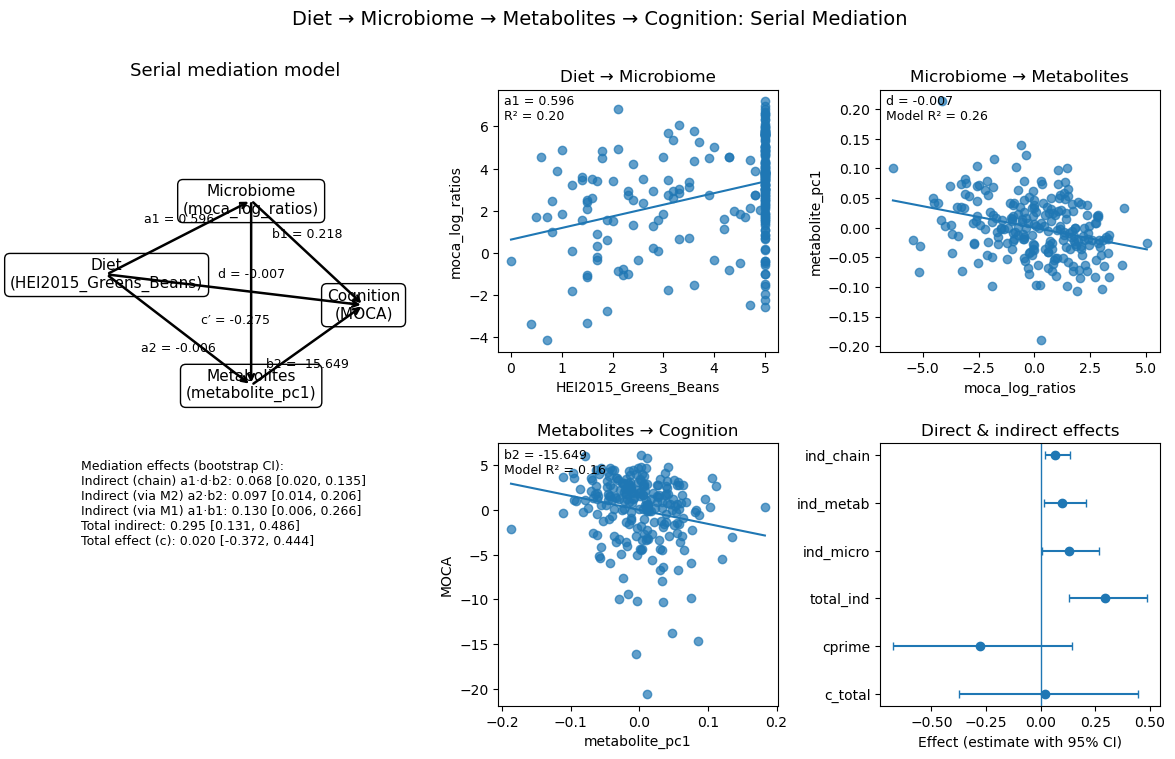

In [529]:
fig = plot_serial_mediation_figure(md, X, M1, M2, Y, covs=covs, effects_table=results, savepath="../figures/serial_mediation.png")
plt.show()

In [530]:
results

,estimate,ci_2.5,ci_97.5
effect,,,
a1,0.595709,0.365779,0.802076
a2,-0.006203,-0.011621,-0.000996
d,-0.007269,-0.010548,-0.003997
b1,0.218199,0.009346,0.436017
b2,-15.648775,-26.457795,-6.185789
cprime,-0.275141,-0.675889,0.144432
c_total,0.019667,-0.372424,0.443861
ind_micro,0.129983,0.006038,0.265641
ind_metab,0.097066,0.013580,0.205836


In [472]:
md["Eicosadienoic_acid"] = diet["Eicosadienoic acid"]

In [475]:
# Define variables 
X  = "Eicosadienoic_acid"
M1 = "moca_log_ratios"
M2 = "metabolite_pc1"
Y  = 'MOCA'

covs = ["NACCAGE", "SEX", "site"]

point, results = serial_mediation_bootstrap(
    df=md, x=X, m1=M1, m2=M2, y=Y,
    covariates=covs,
    n_boot=5000, seed=42
)

print(results.loc[["ind_chain", "ind_micro", "ind_metab", "total_ind", "cprime", "c_total",
                   "prop_mediated_total_ind"]])

                         estimate    ci_2.5   ci_97.5
effect                                               
ind_chain               -0.091084 -0.219486 -0.008241
ind_micro               -0.272081 -0.552157 -0.013580
ind_metab               -0.024035 -0.141426  0.106402
total_ind               -0.387200 -0.684185 -0.103494
cprime                   0.779658  0.095013  1.405779
c_total                  0.392458 -0.210751  0.980984
prop_mediated_total_ind -0.986600 -9.565093  9.070244


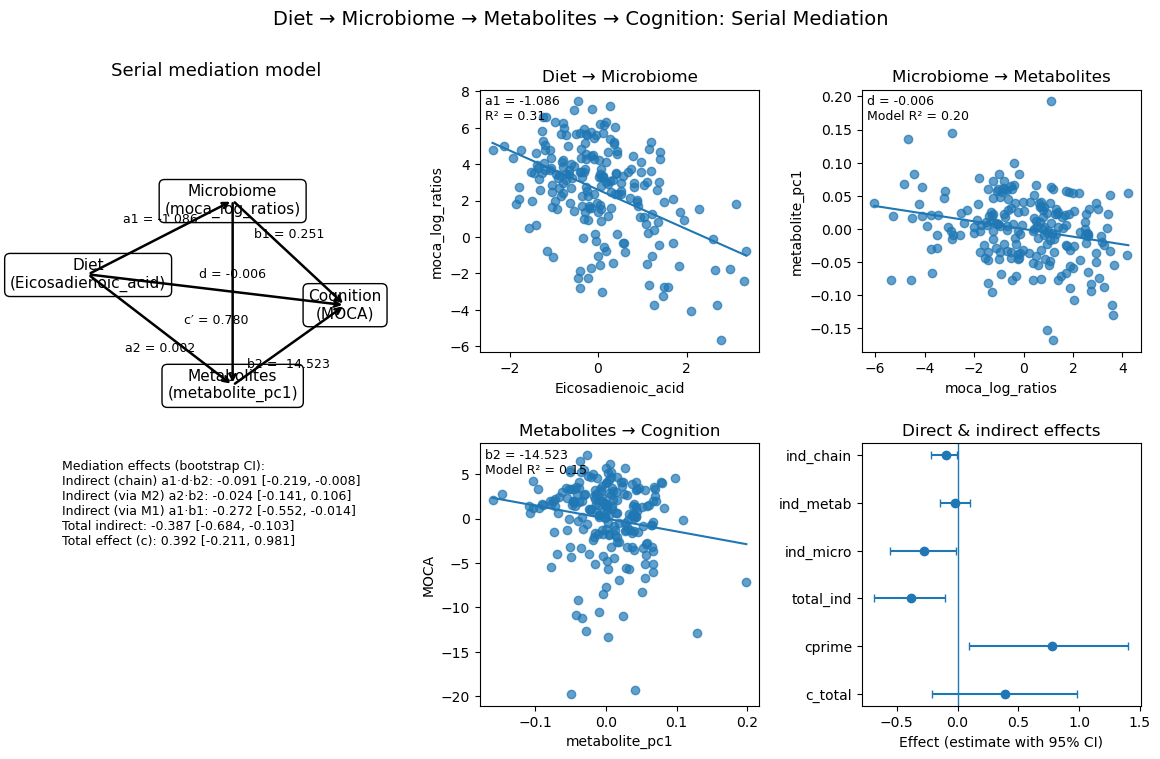

In [476]:
fig = plot_serial_mediation_figure(md, X, M1, M2, Y, covs=covs, effects_table=results, savepath=f"../figures/serial_mediation_{X}.png")
plt.show()

In [534]:
food = food.clip(lower=0)

In [535]:
food_q2 = q2.Artifact.import_data('FeatureTable[Frequency]', food)

In [540]:
from qiime2.plugins import diversity, gemelli, feature_table
import skbio
# beta diversity (rpca) 

rpca = gemelli.methods.rpca(table=food_q2)

ordination = rpca.biplot

# Convert the ordination to a `skbio` OrdinationResults object
ordination = ordination.view(skbio.OrdinationResults)

# Extract the sample coordinates and feature loadings as DataFrames
samples_df = pd.DataFrame(ordination.samples)
features_df = pd.DataFrame(ordination.features)

samples_df = samples_df.rename(columns={0: 'PC1', 1: 'PC2', 2: 'PC3'})
features_df = features_df.rename(columns={0: 'PC1', 1: 'PC2', 2: 'PC3'})

pc_df = samples_df

In [549]:
md['foodomics_pc1'] = pc_df['PC1']

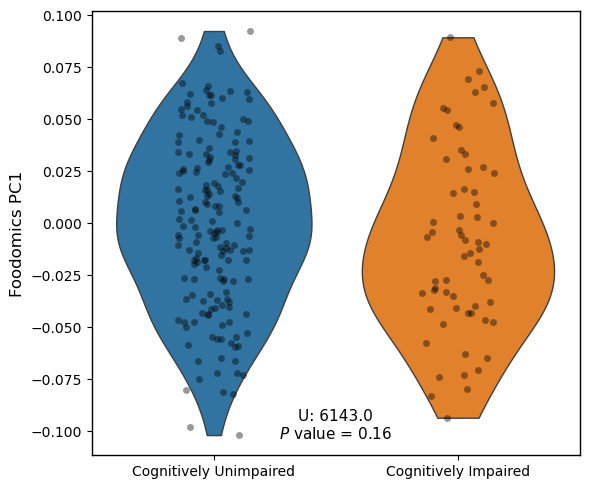

In [550]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, kruskal

test_col = 'foodomics_pc1'
group_col = 'Diagonsis'

ft_test = md.dropna(subset=[test_col, group_col])
groups = ft_test[group_col].unique()
data = [ft_test[ft_test[group_col] == group][test_col] for group in groups]

if len(groups) == 2:
    kw_statistic, kw_pvalue = mannwhitneyu(*data)
    test_name = 'U'
else:
    kw_statistic, kw_pvalue = kruskal(*data)
    test_name = 'KW'

fig, ax = plt.subplots(figsize=(6, 5))

sns.violinplot(
    data=ft_test,
    x=group_col,
    y=test_col,
    inner=None,
    cut=0,
    linewidth=1,
    ax=ax
)

sns.stripplot(
    data=ft_test,
    x=group_col,
    y=test_col,
    color='black',
    alpha=0.4,
    jitter=0.15,
    ax=ax
)

p_value_text = (
    "< .001" if kw_pvalue < 0.001
    else f"= {kw_pvalue:.3f}".lstrip('0') if kw_pvalue < 0.01
    else f"= {kw_pvalue:.2f}".lstrip('0')
)

ax.text(
    0.5, 0.03,
    f'{test_name}: {kw_statistic:.1f}\n$\\mathit{{P}}$ value {p_value_text}',
    ha='center',
    va='bottom',
    fontsize=11,
    transform=ax.transAxes
)

ax.set_xlabel("")
ax.set_ylabel("Foodomics PC1", fontsize=12)

for spine in ax.spines.values():
    spine.set_linewidth(1)
    spine.set_edgecolor('black')

fig.tight_layout()
fig.savefig("../figures/foodomics_pc1_by_diagnosis.png", dpi=600)
plt.show()

In [80]:
df = fts['Metagenomics'][moca_metag['featureid_clean'].str.split(';').str[-1].str.strip()]
# df = resid['Metagenomics'][moca_metag['featureid_clean'].str.split(';').str[-1].str.strip()]

In [81]:
df[['moca_log_ratios', 'metabolite_pc1']] = md[['moca_log_ratios', 'metabolite_pc1']]

/tmp/ipykernel_66689/526210768.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['moca_log_ratios', 'metabolite_pc1']] = md[['moca_log_ratios', 'metabolite_pc1']]
/tmp/ipykernel_66689/526210768.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[['moca_log_ratios', 'metabolite_pc1']] = md[['moca_log_ratios', 'metabolite_pc1']]


In [82]:
df_resid = residualize(df, covars)

In [84]:
df_resid

,G001916165,G000155855,G001603945,G000433515,G000518765,G900539185,G000434055,G900103835,G900547795,G900095865,...,G000438095,G000179635,G003477605,G000421005,G000438215,G000159435,G001042675,G000436455,moca_log_ratios,metabolite_pc1
15448.0042180541,2.100756,0.575306,1.871094,2.052728,1.089917,1.373288,2.066454,0.333266,7.416230,0.467676,...,1.080515,1.704643,3.205083,-0.021224,-1.361243,-1.488623,-1.440408,-2.653095,3.772082,0.091408
15448.0042239290,-0.857012,0.036160,-0.603346,0.017686,-0.241548,-0.487063,0.494999,-0.381902,-1.352388,0.126664,...,-0.674333,-0.500613,-2.389800,0.288745,-0.085639,0.679244,-1.172973,-1.498002,-0.118528,-0.044243
15448.0042036365,0.426400,-1.604582,-0.448425,2.814328,0.093012,-1.087649,0.628949,0.033314,5.167455,-1.073926,...,-0.128986,-0.596743,1.540115,-0.165490,-2.532768,1.055631,0.550001,-2.755834,2.576700,0.062592
15448.0042149798,-1.293244,-0.421725,2.055569,5.800606,0.662314,1.263139,0.363297,0.258605,4.852598,0.031502,...,3.329846,-0.054146,0.735243,-0.373200,2.212376,0.279087,4.542822,2.176853,-1.563755,-0.002633
15448.0042121151,1.982523,0.817188,0.266415,-0.370685,-0.474576,-0.314924,1.112967,-0.315484,-0.212874,0.351399,...,2.993661,0.724315,3.759967,-0.364045,0.001079,-0.747116,1.530710,0.257889,1.605513,0.075428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15448.42430221,1.657594,2.527704,0.505135,-0.936663,0.295891,0.228573,0.027207,-0.153203,1.038656,-0.012458,...,-0.451864,1.684364,0.487477,0.502231,-1.613785,1.212096,-1.113719,-1.136640,2.720406,0.066682
15448.42368299,2.572255,1.203584,0.487980,0.588943,1.435105,0.878294,0.730426,0.065014,0.971943,0.621114,...,2.532562,3.560647,4.056148,-0.451147,-1.980128,-1.039148,-1.209403,-1.992203,4.344870,0.112171
15448.42413913,-2.199531,-0.876716,-2.906044,0.357309,-2.003580,-0.935635,-2.018267,-0.601162,-1.274878,-0.320544,...,-1.272625,-2.311111,-2.188252,-1.650301,3.201019,-0.703103,-0.688852,3.332902,-4.367868,-0.083617
15448.42231863,0.411320,-0.115874,-1.934800,-1.614761,-0.264104,-0.070181,-0.318057,-0.189107,-1.186569,-1.082817,...,-2.060407,0.537118,-1.776606,0.067468,1.297037,-0.249856,-1.442487,1.946503,-2.478739,-0.072342


In [85]:
df_q2 = q2.Artifact.import_data('FeatureTable[Frequency]', df_resid)

In [86]:
df_q2.save('../data/df_for_brain_imaging_residualized.qza')

'../data/df_for_brain_imaging_residualized.qza'

In [88]:
df_q2.view(pd.DataFrame)

,G001916165,G000155855,G001603945,G000433515,G000518765,G900539185,G000434055,G900103835,G900547795,G900095865,...,G000438095,G000179635,G003477605,G000421005,G000438215,G000159435,G001042675,G000436455,moca_log_ratios,metabolite_pc1
15448.0042180541,2.100756,0.575306,1.871094,2.052728,1.089917,1.373288,2.066454,0.333266,7.416230,0.467676,...,1.080515,1.704643,3.205083,-0.021224,-1.361243,-1.488623,-1.440408,-2.653095,3.772082,0.091408
15448.0042239290,-0.857012,0.036160,-0.603346,0.017686,-0.241548,-0.487063,0.494999,-0.381902,-1.352388,0.126664,...,-0.674333,-0.500613,-2.389800,0.288745,-0.085639,0.679244,-1.172973,-1.498002,-0.118528,-0.044243
15448.0042036365,0.426400,-1.604582,-0.448425,2.814328,0.093012,-1.087649,0.628949,0.033314,5.167455,-1.073926,...,-0.128986,-0.596743,1.540115,-0.165490,-2.532768,1.055631,0.550001,-2.755834,2.576700,0.062592
15448.0042149798,-1.293244,-0.421725,2.055569,5.800606,0.662314,1.263139,0.363297,0.258605,4.852598,0.031502,...,3.329846,-0.054146,0.735243,-0.373200,2.212376,0.279087,4.542822,2.176853,-1.563755,-0.002633
15448.0042121151,1.982523,0.817188,0.266415,-0.370685,-0.474576,-0.314924,1.112967,-0.315484,-0.212874,0.351399,...,2.993661,0.724315,3.759967,-0.364045,0.001079,-0.747116,1.530710,0.257889,1.605513,0.075428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15448.42430221,1.657594,2.527704,0.505135,-0.936663,0.295891,0.228573,0.027207,-0.153203,1.038656,-0.012458,...,-0.451864,1.684364,0.487477,0.502231,-1.613785,1.212096,-1.113719,-1.136640,2.720406,0.066682
15448.42368299,2.572255,1.203584,0.487980,0.588943,1.435105,0.878294,0.730426,0.065014,0.971943,0.621114,...,2.532562,3.560647,4.056148,-0.451147,-1.980128,-1.039148,-1.209403,-1.992203,4.344870,0.112171
15448.42413913,-2.199531,-0.876716,-2.906044,0.357309,-2.003580,-0.935635,-2.018267,-0.601162,-1.274878,-0.320544,...,-1.272625,-2.311111,-2.188252,-1.650301,3.201019,-0.703103,-0.688852,3.332902,-4.367868,-0.083617
15448.42231863,0.411320,-0.115874,-1.934800,-1.614761,-0.264104,-0.070181,-0.318057,-0.189107,-1.186569,-1.082817,...,-2.060407,0.537118,-1.776606,0.067468,1.297037,-0.249856,-1.442487,1.946503,-2.478739,-0.072342


In [ ]:
q2.Artifact.load('../data/df_for_brain_imaging.qza').view(pd.DataFrame)

In [ ]:
from biom import Table

df_biom = Table(df.values, df.index, df.columns)

In [ ]:
df_biom

In [ ]:
print(type(df_biom))

In [ ]:
from biom.util import biom_open

out_fp = "../output_files/df_for_brain_imaging.biom"
with biom_open(out_fp, "w") as f:
    df_biom.to_hdf5(f, "Generated by script")

In [ ]:
load_table("../output_files/df_for_brain_imaging.biom").to_dataframe()

In [ ]:
df.to_csv('../output_files/df_for_brain_imaging.csv')

In [ ]:
fts['Metagenomics']['G001916165']

In [ ]:
df